# Hamiltonian Monte Carlo reconstruction for SPECT

This notebook provides an illustrative implementation of the **Hamiltonian Monte Carlo (HMC)** reconstruction workflow developed within the **PERSPECT** project.

The example reconstructs a selected slice from a measured SPECT sinogram and demonstrates two forward models:

1. **Geometric model** — HMC using a projection matrix generated from the Radon transform.
2. **GATE-corrected model** — HMC using a projection matrix modified with voxel-dependent information obtained from GATE simulations, thereby introducing attenuation/scatter information into the forward model.

For reference, an **MLEM reconstruction** is also performed using the geometric projection matrix.

Unlike a deterministic reconstruction that returns a single image, HMC generates an **ensemble of statistically acceptable reconstructed images**. The ensemble can therefore be used to study the mean reconstruction, fluctuations, correlations, and data-visible uncertainty.

> **Note:** This notebook is an illustrative research implementation intended for methodological development and reproducibility. It is not a clinical reconstruction package.


## Requirements and input files

The notebook requires Python packages including **NumPy**, **TensorFlow**, **SciPy**, **pydicom**, **scikit-image**, **Matplotlib**, and **tqdm**.

The example expects the following input files in the working directory:

- `TOMOCT_EM001_DS.dcm` — SPECT acquisition stored as DICOM.
- `projections_ideal_WC.pk` — voxel-dependent projection information generated from the corresponding GATE workflow and used to construct the attenuation/scatter-corrected projection matrix.
- `pmatrix_geo.pk` — optional cached geometric projection matrix. If it is absent, the notebook generates it from the Radon transform and saves it for reuse.

If required, install the main dependencies with:

```bash
pip install numpy tensorflow scipy pydicom scikit-image matplotlib tqdm
```


## 1. Definitions and reconstruction utilities


In [1]:
from collections import deque
from typing import Any, Optional
from pathlib import Path

import os
import sys
import time
import pickle as pk

import numpy as np
import tensorflow as tf
import pydicom
import matplotlib.pyplot as plt

from scipy.ndimage import convolve, binary_fill_holes
from skimage.transform import radon
from tqdm import tqdm


The following cells define the numerical utilities used by the example, including SGD/MLEM initialization, HMC sampling, ensemble-correlation diagnostics, and data-visible uncertainty maps. The core reconstruction functions are kept unchanged from the working research implementation.


In [2]:


def printProgressBar(iteration, total, suffix="", length=50):
    """
    Simple progress bar.
    """
    if total <= 0:
        total = 1

    percent = 100.0 * iteration / float(total)
    filledLength = int(length * iteration // total)

    bar = "█" * filledLength + "-" * (length - filledLength)

    print(
        f"\r|{bar}| {percent:6.2f}% {suffix}",
        end="\r"
    )

    if iteration >= total:
        print()




def sgd_reconstruction(
    pmatrix_gpu,
    sinogram0,
    ndim,
    n_iter=1000,
    initial_lr=0.1,
    epsilon=1.0,
    sigma=0.0,
    patience=10,
    lr_decay=0.99,

    # Data fidelity model
    loss_type="chi2",            # "chi2" | "poisson" | "poisson_deviance"
    poisson_epsilon=1e-6,

    # Total-count normalization penalty
    normalize_counts_penalty=False,
    count_penalty_weight=1.0,
    count_penalty_epsilon=1e-6,

    # Automatic stopping
    auto_stop=True,
    stop_min_iter=50,
    stop_patience=30,
    stop_rel_tol=1e-5,

    seed=1234,
    printout=True,
):
    """
    Reconstruct a non-negative image from a zero initial state using Adam.

    The data-fidelity term can be either weighted chi-square or Poisson
    deviance. The projection matrix may be dense or a ``tf.SparseTensor``.

    Returns
    -------
    reconstructed_image : ndarray, shape (ndim, ndim)
        Best non-negative image found during optimization.

    forward_projection : ndarray, shape (nangle * nrays,)
        Forward projection of the best image.

    loss_vals : list of float
        Total objective values evaluated during optimization.

    Notes
    -----
    * Initialization is always a zero image.
    * Non-negativity is imposed by projected optimization: after each Adam
      update the image is clipped to zero.
    * If ``sigma > 0``, a 3x3 Gaussian smoothing projection is applied after
      each optimizer update.
    * The stored best image is the exact state at which its objective value was
      evaluated.
    """

    # ------------------------------------------------------------------
    # Validation and setup
    # ------------------------------------------------------------------
    valid_losses = {"chi2", "poisson", "poisson_deviance"}
    if loss_type not in valid_losses:
        raise ValueError(
            "loss_type must be 'chi2', 'poisson', or 'poisson_deviance'."
        )

    ndim = int(ndim)
    n_iter = int(n_iter)
    patience = int(patience)
    stop_min_iter = int(stop_min_iter)
    stop_patience = int(stop_patience)

    if ndim <= 0:
        raise ValueError("ndim must be positive.")
    if n_iter <= 0:
        raise ValueError("n_iter must be positive.")
    if initial_lr <= 0.0:
        raise ValueError("initial_lr must be positive.")
    if patience <= 0:
        raise ValueError("patience must be positive.")
    if not (0.0 < lr_decay <= 1.0):
        raise ValueError("lr_decay must lie in (0, 1].")
    if poisson_epsilon <= 0.0:
        raise ValueError("poisson_epsilon must be positive.")
    if count_penalty_epsilon <= 0.0:
        raise ValueError("count_penalty_epsilon must be positive.")

    tf.random.set_seed(int(seed))
    np.random.seed(int(seed))

    sinogram_np = np.asarray(sinogram0, dtype=np.float32)
    if sinogram_np.ndim != 2:
        raise ValueError("sinogram0 must be a two-dimensional array.")
    if not np.all(np.isfinite(sinogram_np)):
        raise ValueError("sinogram0 contains NaN or infinite values.")
    if np.any(sinogram_np < 0.0):
        raise ValueError("sinogram0 must be non-negative.")

    nangle, nrays = map(int, sinogram_np.shape)
    nbins = nangle * nrays
    npixels = ndim * ndim

    sinogram = tf.constant(sinogram_np.reshape(-1), dtype=tf.float32)
    experimental_total_counts = tf.reduce_sum(sinogram)

    # Keep sparse matrices sparse; cast dense matrices only once.
    matrix_is_sparse = isinstance(pmatrix_gpu, tf.SparseTensor)

    if matrix_is_sparse:
        pmatrix = tf.SparseTensor(
            indices=pmatrix_gpu.indices,
            values=tf.cast(pmatrix_gpu.values, tf.float32),
            dense_shape=pmatrix_gpu.dense_shape,
        )
        pmatrix = tf.sparse.reorder(pmatrix)
        matrix_shape = tuple(int(v) for v in pmatrix.shape)
    else:
        pmatrix = tf.convert_to_tensor(pmatrix_gpu, dtype=tf.float32)
        matrix_shape = tuple(int(v) for v in pmatrix.shape)

    expected_shape = (nbins, npixels)
    if matrix_shape != expected_shape:
        raise ValueError(
            f"pmatrix_gpu has shape {matrix_shape}, expected {expected_shape}."
        )

    # The optimizer always starts from zero.
    reconstructed_image = tf.Variable(
        tf.zeros([npixels], dtype=tf.float32)
    )

    # ------------------------------------------------------------------
    # Constants used by the loss
    # ------------------------------------------------------------------
    if loss_type == "chi2":
        denominator = sinogram + tf.cast(epsilon, tf.float32)
        if np.any(sinogram_np.reshape(-1) + float(epsilon) <= 0.0):
            raise ValueError("sinogram + epsilon must be strictly positive.")
        chi2_weights = tf.math.reciprocal(denominator)
        poisson_constant = None
        data_loss_name = "Chi2"
    else:
        chi2_weights = None
        poisson_constant = tf.math.xlogy(
            sinogram,
            sinogram + tf.cast(poisson_epsilon, tf.float32),
        )
        data_loss_name = "PoissonDev"

    # ------------------------------------------------------------------
    # Optional TensorFlow image-smoothing kernel
    # ------------------------------------------------------------------
    image_kernel_4d = None
    image_pad = 0

    if sigma > 0.0:
        kernel_size = 3
        axis = np.linspace(
            -(kernel_size // 2),
            kernel_size // 2,
            kernel_size,
            dtype=np.float32,
        )
        xx, yy = np.meshgrid(axis, axis, indexing="xy")
        kernel_np = np.exp(
            -0.5 * (xx * xx + yy * yy) / (float(sigma) ** 2)
        ).astype(np.float32)

        kernel_sum = float(kernel_np.sum())
        if not np.isfinite(kernel_sum) or kernel_sum <= 0.0:
            raise ValueError("Invalid Gaussian smoothing kernel.")

        kernel_np /= kernel_sum
        image_kernel_4d = tf.constant(
            kernel_np[:, :, None, None], dtype=tf.float32
        )
        image_pad = kernel_size // 2

    # ------------------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------------------
    current_lr = float(initial_lr)
    optimizer = tf.keras.optimizers.Adam(learning_rate=current_lr)

    if hasattr(optimizer, "build"):
        optimizer.build([reconstructed_image])

    # ------------------------------------------------------------------
    # Forward model and loss
    # ------------------------------------------------------------------
    def project_image(image_flat):
        if matrix_is_sparse:
            return tf.sparse.sparse_dense_matmul(
                pmatrix, image_flat[:, None]
            )[:, 0]
        return tf.linalg.matvec(pmatrix, image_flat)

    def loss_components():
        yhat = project_image(reconstructed_image)

        if loss_type == "chi2":
            residual = sinogram - yhat
            data_loss = tf.reduce_mean(
                tf.square(residual) * chi2_weights
            )
        else:
            # The physical forward model is expected to be non-negative.
            # epsilon keeps log(mu) finite while preserving gradients.
            mu_safe = yhat + tf.cast(poisson_epsilon, tf.float32)
            data_loss = 2.0 * tf.reduce_mean(
                mu_safe
                - sinogram
                + poisson_constant
                - tf.math.xlogy(sinogram, mu_safe)
            )

        predicted_total_counts = tf.reduce_sum(yhat)

        if normalize_counts_penalty:
            relative_count_error = (
                predicted_total_counts - experimental_total_counts
            ) / (
                experimental_total_counts
                + tf.cast(count_penalty_epsilon, tf.float32)
            )
            count_penalty = tf.cast(
                count_penalty_weight, tf.float32
            ) * tf.square(relative_count_error)
        else:
            count_penalty = tf.constant(0.0, dtype=tf.float32)

        total_loss = data_loss + count_penalty

        return (
            total_loss,
            data_loss,
            count_penalty,
            predicted_total_counts,
        )

    # ------------------------------------------------------------------
    # Compiled gradient/update/evaluation functions
    # ------------------------------------------------------------------
    @tf.function(reduce_retracing=True)
    def compute_loss_and_gradient():
        with tf.GradientTape() as tape:
            values = loss_components()
            total_loss = values[0]

        image_grad = tape.gradient(total_loss, reconstructed_image)
        return (*values, image_grad)

    @tf.function(reduce_retracing=True)
    def apply_update(image_grad):
        optimizer.apply_gradients([(image_grad, reconstructed_image)])

        # Project onto the non-negative image domain.
        reconstructed_image.assign(
            tf.maximum(reconstructed_image, 0.0)
        )

        if image_kernel_4d is not None:
            image4 = tf.reshape(
                reconstructed_image, [1, ndim, ndim, 1]
            )
            image4 = tf.pad(
                image4,
                [
                    [0, 0],
                    [image_pad, image_pad],
                    [image_pad, image_pad],
                    [0, 0],
                ],
                mode="REFLECT",
            )
            smoothed4 = tf.nn.conv2d(
                image4,
                image_kernel_4d,
                strides=[1, 1, 1, 1],
                padding="VALID",
            )
            reconstructed_image.assign(tf.reshape(smoothed4, [-1]))

    @tf.function(reduce_retracing=True)
    def evaluate_loss_only():
        return loss_components()

    @tf.function(reduce_retracing=True)
    def forward_from_state(image_state):
        return project_image(image_state)

    # ------------------------------------------------------------------
    # Progress output
    # ------------------------------------------------------------------
    def print_progress(current, total, text):
        if not printout:
            return

        total = max(int(total), 1)
        fraction_done = min(max(current / total, 0.0), 1.0)
        bar_length = 30
        filled = int(round(bar_length * fraction_done))
        bar = "=" * filled + "-" * (bar_length - filled)

        print(
            f"\r[{bar}] {100.0 * fraction_done:6.2f}% | {text}",
            end="",
            flush=True,
        )

    print_stride = max(1, n_iter // 100)

    # ------------------------------------------------------------------
    # Histories and stopping state
    # ------------------------------------------------------------------
    loss_vals = []
    data_loss_vals = []
    count_penalty_vals = []

    best_loss = float("inf")
    reconstructed_image_best = None

    best_lr_loss = float("inf")
    lr_patience_counter = 0
    lr_rel_tol = 1.0e-3

    best_stop_loss = float("inf")
    stop_counter = 0
    stopped_early = False

    # ------------------------------------------------------------------
    # Optimization loop
    # ------------------------------------------------------------------
    for it in range(n_iter):
        (
            total_loss,
            data_loss,
            count_penalty,
            predicted_total_counts,
            image_grad,
        ) = compute_loss_and_gradient()

        if image_grad is None:
            raise RuntimeError("The image gradient is None.")

        # One host synchronization for scalar diagnostics.
        scalar_values = tf.stack(
            [
                total_loss,
                data_loss,
                count_penalty,
                predicted_total_counts,
            ]
        ).numpy()

        loss_value = float(scalar_values[0])
        data_loss_value = float(scalar_values[1])
        count_penalty_value = float(scalar_values[2])
        predicted_total_value = float(scalar_values[3])

        if not np.isfinite(loss_value):
            raise FloatingPointError(
                f"Non-finite loss at iteration {it}: {loss_value}. "
                "For Poisson loss, verify that the projection matrix and "
                "predicted counts are non-negative."
            )

        loss_vals.append(loss_value)
        data_loss_vals.append(data_loss_value)
        count_penalty_vals.append(count_penalty_value)

        # Save the exact pre-update state associated with this loss.
        if loss_value < best_loss:
            best_loss = loss_value
            reconstructed_image_best = tf.identity(reconstructed_image)

        # --------------------------------------------------------------
        # Learning-rate plateau logic
        # --------------------------------------------------------------
        if not np.isfinite(best_lr_loss):
            best_lr_loss = loss_value
            lr_patience_counter = 0
        else:
            relative_lr_improvement = (
                best_lr_loss - loss_value
            ) / (abs(best_lr_loss) + 1.0e-12)

            if relative_lr_improvement > lr_rel_tol:
                best_lr_loss = loss_value
                lr_patience_counter = 0
            else:
                lr_patience_counter += 1

                if lr_patience_counter >= patience:
                    current_lr = max(
                        current_lr * float(lr_decay), 1.0e-6
                    )
                    optimizer.learning_rate.assign(current_lr)

                    best_lr_loss = loss_value
                    lr_patience_counter = 0

        # --------------------------------------------------------------
        # Automatic stopping
        # --------------------------------------------------------------
        if not np.isfinite(best_stop_loss):
            best_stop_loss = loss_value
            stop_counter = 0
        else:
            relative_stop_improvement = (
                best_stop_loss - loss_value
            ) / (abs(best_stop_loss) + 1.0e-12)

            if relative_stop_improvement > stop_rel_tol:
                best_stop_loss = loss_value
                stop_counter = 0
            elif it >= stop_min_iter:
                stop_counter += 1
            elif loss_value < best_stop_loss:
                best_stop_loss = loss_value

        if (
            auto_stop
            and it >= stop_min_iter
            and stop_counter >= stop_patience
        ):
            stopped_early = True
            if printout:
                print(
                    f"\nStopped automatically at iteration {it}. "
                    f"Loss = {loss_value:.8g}, "
                    f"best loss = {best_loss:.8g}"
                )
            break

        # Apply update only after saving/evaluating the current state.
        apply_update(image_grad)

        # --------------------------------------------------------------
        # Progress display
        # --------------------------------------------------------------
        if it % print_stride == 0 or it == n_iter - 1:
            if normalize_counts_penalty:
                experimental_total_value = float(
                    experimental_total_counts.numpy()
                )
                count_ratio = predicted_total_value / (
                    experimental_total_value + 1.0e-12
                )
                progress_text = (
                    f"Loss={loss_value:.8g} | "
                    f"{data_loss_name}={data_loss_value:.8g} | "
                    f"Count ratio={count_ratio:.6f} | "
                    f"LR={current_lr:.3e}"
                )
            else:
                progress_text = (
                    f"Loss={loss_value:.8g} | "
                    f"{data_loss_name}={data_loss_value:.8g} | "
                    f"LR={current_lr:.3e}"
                )

            print_progress(it + 1, n_iter, progress_text)

    # ------------------------------------------------------------------
    # Evaluate final post-update state so the last update can become best
    # ------------------------------------------------------------------
    final_values = evaluate_loss_only()
    final_scalar_values = tf.stack(final_values).numpy()
    final_current_loss = float(final_scalar_values[0])

    if np.isfinite(final_current_loss) and final_current_loss < best_loss:
        best_loss = final_current_loss
        reconstructed_image_best = tf.identity(reconstructed_image)

    if reconstructed_image_best is None:
        raise RuntimeError("No valid reconstruction state was produced.")

    # ------------------------------------------------------------------
    # Final forward projection from the exact best state
    # ------------------------------------------------------------------
    forward_projection = forward_from_state(reconstructed_image_best)

    final_pred_counts = float(tf.reduce_sum(forward_projection).numpy())
    final_exp_counts = float(experimental_total_counts.numpy())
    final_count_ratio = final_pred_counts / (final_exp_counts + 1.0e-12)

    if printout:
        print()
        print(f"best loss = {best_loss:.8g}  ({loss_type})")
        print(
            "final reconstructed / experimental counts = "
            f"{final_count_ratio:.8g}"
        )
        if stopped_early:
            print("Automatic convergence stop was activated.")

    return (
        tf.reshape(reconstructed_image_best, (ndim, ndim)).numpy(),
        forward_projection.numpy(),
        loss_vals,
    )


def _print_progress_bar(iteration: int, total: int, text: str = "", length: int = 28) -> None:
    """Small self-contained progress display."""
    total = max(int(total), 1)
    iteration = min(max(int(iteration), 0), total)
    fraction = iteration / total
    filled = int(round(length * fraction))
    bar = "█" * filled + "-" * (length - filled)
    end = "\n" if iteration >= total else "\r"
    print(f"|{bar}| {100.0 * fraction:6.2f}% {text}", end=end, flush=True)


def HMC_reconstruction(
    sinogram,
    pmatrix_gpu,
    ndim,
    nini,
    ntherm,
    num_samples,
    nthread,
    factor,
    T=1.0,
    printout=True,
    L0=20,
    sigma=1.0,
    AMIAS=True,
    plot=False,
    usechi2map=True,

    # Reconstruction / proposal options
    step0=1.0,
    fraction=1.0,
    maxstep=None,
    mask=None,
    force_positive=False,
    mass=1.0,
    positivity_mode="clip",       # "reflect" | "project" | "clip" | "none"
    adapt0=0.05,
    adapt_power=0.6,
    target_accept=0.70,
    adapt_during_sampling=True,
    getensemble=True,
    max_overshoot=1.0,

    # Initialization
    cold_start=False,
    sgd_kwargs=None,

    # Diagnostics
    diagnostic_window=50,
    movement_tolerance=0.0,
    store_proposal_debug=True,
    proposal_debug_stride=1,
    store_exchange_debug=True,
    exchange_debug_stride=1,

    # Momentum / reproducibility
    randomize_momenta=False,
    flip_momentum_on_reject=False,
    random_seed=None,
):
    """
    AMIAS/HMC-style image reconstruction with optional parallel tempering.

    AMIAS=True
    ----------
    The Metropolis test uses only the reconstruction objective chi2:

        p_accept = min(1, exp(-(chi2_candidate - chi2_current) / T))

    The momenta and leapfrog equations are used only to construct proposals.
    Kinetic energy is deliberately excluded from the AMIAS acceptance rule.

    AMIAS=False
    -----------
    The Metropolis test uses the total Hamiltonian:

        H = chi2 + kinetic_energy

    Important implementation details
    --------------------------------
    1. `temperingorder[k]` is the physical chain occupying temperature-ladder
       position k. The temperature ladder itself remains fixed.
    2. Step sizes and ladder acceptance statistics are indexed by temperature
       position, not by physical-chain identity.
    3. The progress objective is always recomputed from the accepted/current
       image (`image2_gpu`), never from the last proposal.
    4. Recent cold-ladder acceptance, mean acceptance probability, and actual
       movement are reported separately from lifetime physical-chain ratios.
    5. When AMIAS=True and momenta are randomized, `current_objective` remains
       chi2; it is never overwritten by total Hamiltonian.

    Initialization
    --------------
    By default (`cold_start=False`), `sgd_reconstruction` is called internally.
    It starts from zero and its best non-negative reconstruction is copied to
    every HMC/AMIAS chain.

    If `cold_start=True`, the SGD/Adam initialization is skipped and all chains
    start directly from zero.

    Optional SGD settings can be supplied through `sgd_kwargs`.

    Notes
    -----
    `positivity_mode="clip"` and `"project"` are useful numerical constraints,
    but they are not reversible Hamiltonian boundary treatments. For the most
    HMC-like constrained dynamics, prefer `"reflect"` without triggering the
    large-overshoot projection branch.
    """

    # ------------------------------------------------------------------
    # Validate scalar arguments
    # ------------------------------------------------------------------
    ndim = int(ndim)
    nini = int(nini)
    ntherm = int(ntherm)
    num_samples = int(num_samples)
    nthread = int(nthread)
    L = int(L0)

    if ndim <= 0:
        raise ValueError("ndim must be positive.")
    if nthread <= 0:
        raise ValueError("nthread must be positive.")
    if ntherm <= 0:
        raise ValueError("ntherm must be positive.")
    if num_samples <= 0:
        raise ValueError("num_samples must be positive.")
    if L <= 0:
        raise ValueError("L0 must be positive.")
    if T <= 0:
        raise ValueError("T must be positive.")
    if factor <= 0:
        raise ValueError("factor must be positive.")
    if nthread > 1 and factor < 1.0:
        raise ValueError("factor must be >= 1 when nthread > 1.")
    if step0 <= 0:
        raise ValueError("step0 must be positive.")
    if not (0.0 < fraction <= 1.0):
        raise ValueError("fraction must satisfy 0 < fraction <= 1.")
    if not (0.0 <= target_accept <= 1.0):
        raise ValueError("target_accept must be between 0 and 1.")
    if diagnostic_window <= 0:
        raise ValueError("diagnostic_window must be positive.")
    if proposal_debug_stride <= 0:
        raise ValueError("proposal_debug_stride must be positive.")
    if exchange_debug_stride <= 0:
        raise ValueError("exchange_debug_stride must be positive.")
    if max_overshoot < 0.0:
        raise ValueError("max_overshoot must be non-negative.")
    if positivity_mode not in {"reflect", "project", "clip", "none"}:
        raise ValueError(
            "positivity_mode must be 'reflect', 'project', 'clip', or 'none'."
        )

    # ------------------------------------------------------------------
    # Reproducible random generators
    # ------------------------------------------------------------------
    if random_seed is None:
        initial_random_seed = int(np.random.SeedSequence().generate_state(1)[0])
    else:
        initial_random_seed = int(random_seed)

    rng = np.random.default_rng(initial_random_seed)
    tf.random.set_seed(initial_random_seed)

    # ------------------------------------------------------------------
    # Input geometry
    # ------------------------------------------------------------------
    sinogram_np = np.asarray(sinogram, dtype=np.float32)
    if sinogram_np.ndim != 2:
        raise ValueError(
            f"sinogram must be a 2-D array, received shape {sinogram_np.shape}."
        )

    nangle = int(sinogram_np.shape[0])
    nrays = int(sinogram_np.shape[1])
    npixels = int(ndim * ndim)
    nbins = int(nangle * nrays)

    # Static matrix-shape checks when TensorFlow knows the dimensions.
    pmatrix_gpu = tf.convert_to_tensor(pmatrix_gpu)
    if pmatrix_gpu.dtype != tf.float32:
        pmatrix_gpu = tf.cast(pmatrix_gpu, tf.float32)

    pshape = tuple(pmatrix_gpu.shape.as_list()) if hasattr(
        pmatrix_gpu.shape, "as_list"
    ) else tuple(pmatrix_gpu.shape)

    if len(pshape) != 2:
        raise ValueError(f"pmatrix_gpu must be rank 2, received shape {pshape}.")
    if pshape[0] is not None and int(pshape[0]) != nbins:
        raise ValueError(
            f"pmatrix_gpu has {pshape[0]} rows, but sinogram has {nbins} bins."
        )
    if pshape[1] is not None and int(pshape[1]) != npixels:
        raise ValueError(
            f"pmatrix_gpu has {pshape[1]} columns, but expected {npixels} pixels."
        )

    chi2min = np.inf
    image_min = np.zeros(npixels, dtype=np.float32)

    # ------------------------------------------------------------------
    # Mask
    # ------------------------------------------------------------------
    if mask is None:
        mask_flat = np.ones((npixels, 1), dtype=np.float32)
    else:
        mask_arr = np.asarray(mask, dtype=np.float32)
        if mask_arr.size != npixels:
            raise ValueError(
                f"mask has {mask_arr.size} elements, expected {npixels}."
            )
        mask_flat = mask_arr.reshape(npixels, 1)

    mask_flat = (mask_flat > 0).astype(np.float32)
    mask_gpu = tf.constant(mask_flat, dtype=tf.float32)
    active_indices_gpu = tf.cast(
        tf.reshape(tf.where(mask_gpu[:, 0] > 0.0), [-1]),
        tf.int32,
    )

    n_active = int(np.sum(mask_flat[:, 0] > 0.0))
    if n_active == 0:
        raise ValueError("mask contains no active pixels.")

    # ------------------------------------------------------------------
    # Initial image ensemble, shape (npixels, nthread)
    #
    # cold_start=False (default): obtain an internal SGD/Adam reconstruction
    # and use it to initialize every chain.
    #
    # cold_start=True: skip SGD and initialize every chain from zero.
    # ------------------------------------------------------------------
    sgd_image = None
    sgd_forward_projection = None
    sgd_loss_vals = None
    sgd_options_used = None

    image_init = np.zeros((npixels, nthread), dtype=np.float32)

    if not bool(cold_start):
        if sgd_kwargs is None:
            user_sgd_kwargs = {}
        elif isinstance(sgd_kwargs, dict):
            user_sgd_kwargs = dict(sgd_kwargs)
        else:
            raise TypeError("sgd_kwargs must be a dict or None.")

        # Match the HMC weighted chi-square denominator by default.
        # When usechi2map=False, retain the SGD routine's conventional epsilon=1.
        default_sgd_epsilon = float(sigma) if usechi2map else 1.0

        sgd_options_used = {
            "n_iter": 10000,
            "initial_lr": 0.1,
            "epsilon": default_sgd_epsilon,
            "sigma": 0.0,
            "patience": 10,
            "lr_decay": 0.99,
            "loss_type": "chi2",
            "poisson_epsilon": 1.0e-6,
            "normalize_counts_penalty": False,
            "count_penalty_weight": 1.0,
            "count_penalty_epsilon": 1.0e-6,
            "auto_stop": True,
            "stop_min_iter": 50,
            "stop_patience": 30,
            "stop_rel_tol": 1.0e-5,
            "seed": int(initial_random_seed),
            "printout": bool(printout),
        }
        sgd_options_used.update(user_sgd_kwargs)

        # Keep the initializer consistent with the HMC objective family.
        if sgd_options_used.get("loss_type") != "chi2":
            raise ValueError(
                "The internal HMC initializer must use loss_type='chi2' "
                "to remain consistent with the HMC objective."
            )
        if printout:
            print("initialization: internal sgd_reconstruction")

        sgd_image, sgd_forward_projection, sgd_loss_vals = sgd_reconstruction(
            pmatrix_gpu=pmatrix_gpu,
            sinogram0=sinogram_np,
            ndim=ndim,
            **sgd_options_used,
        )

        sgd_image_flat = np.asarray(sgd_image, dtype=np.float32).reshape(-1)
        if sgd_image_flat.size != npixels:
            raise RuntimeError(
                "Internal SGD initialization returned an image with "
                f"{sgd_image_flat.size} pixels; expected {npixels}."
            )
        if not np.all(np.isfinite(sgd_image_flat)):
            raise FloatingPointError(
                "Internal SGD initialization returned NaN or infinite values."
            )

        # Apply the HMC support mask before copying the state to all chains.
        sgd_image_flat = np.maximum(sgd_image_flat, 0.0)
        sgd_image_flat *= mask_flat[:, 0]
        image_init[:] = sgd_image_flat[:, None]

    elif printout:
        print("initialization: cold start from zero")

    image2_gpu = tf.Variable(image_init, dtype=tf.float32)
    image2_gpu.assign(image2_gpu * mask_gpu)

    image_temp_gpu = tf.Variable(
        np.zeros((npixels, nthread), dtype=np.float32),
        dtype=tf.float32,
    )

    # ------------------------------------------------------------------
    # Mass: scalar or one value per pixel
    # ------------------------------------------------------------------
    mass_arr = np.asarray(mass, dtype=np.float32)
    if mass_arr.ndim == 0:
        if float(mass_arr) <= 0.0:
            raise ValueError("mass must be positive.")
        mass_vec_np = np.full(npixels, float(mass_arr), dtype=np.float32)
    else:
        mass_vec_np = mass_arr.ravel()
        if mass_vec_np.size != npixels:
            raise ValueError(
                f"mass has {mass_vec_np.size} elements, expected {npixels}."
            )
        if np.any(mass_vec_np <= 0.0):
            raise ValueError("all mass values must be positive.")

    mass_gpu = tf.constant(mass_vec_np[:, None], dtype=tf.float32)

    # ------------------------------------------------------------------
    # Sinogram and chi2 weights
    # ------------------------------------------------------------------
    sinogram_flat = sinogram_np.ravel()
    sinogram_gpu = tf.constant(sinogram_flat, dtype=tf.float32)

    if usechi2map:
        denominator = sinogram_flat + float(sigma)
        if np.any(denominator <= 0.0):
            raise ValueError(
                "sinogram + sigma must be strictly positive when usechi2map=True."
            )
        chi2map_np = 1.0 / denominator
    else:
        chi2map_np = np.ones_like(sinogram_flat, dtype=np.float32)

    chi2map_gpu = tf.constant(chi2map_np, dtype=tf.float32)

    # ------------------------------------------------------------------
    # Momenta, shape (npixels, nthread)
    # ------------------------------------------------------------------
    momenta_gpu = tf.Variable(
        np.zeros((npixels, nthread), dtype=np.float32),
        dtype=tf.float32,
    )

    # ------------------------------------------------------------------
    # Objective and analytic gradient
    # ------------------------------------------------------------------
    def objective_function(params):
        """Return one mean weighted squared residual per physical chain."""
        params = tf.cast(params, tf.float32) * mask_gpu

        prediction = tf.transpose(
            tf.matmul(pmatrix_gpu, params)
        )  # (nthread, nbins)

        residual = prediction - sinogram_gpu
        return tf.reduce_mean(
            tf.square(residual) * chi2map_gpu,
            axis=1,
        )

    def dobjective_function(params):
        """Analytic gradient of `objective_function`."""
        params = tf.cast(params, tf.float32) * mask_gpu

        prediction = tf.transpose(
            tf.matmul(pmatrix_gpu, params)
        )  # (nthread, nbins)

        nbins_tf = tf.cast(tf.size(sinogram_gpu), tf.float32)
        weighted_residual = (
            (prediction - sinogram_gpu) * chi2map_gpu / nbins_tf
        )

        grad = 2.0 * tf.transpose(
            tf.matmul(weighted_residual, pmatrix_gpu)
        )
        return grad * mask_gpu

    def hamiltonian(params, momenta):
        potential_energy = objective_function(params)
        kinetic_energy = 0.5 * tf.reduce_sum(
            tf.square(momenta) / mass_gpu,
            axis=0,
        )
        return potential_energy + kinetic_energy

    # ------------------------------------------------------------------
    # Leapfrog proposal generator
    # ------------------------------------------------------------------
    def leapfrog_optimized(
        weights,
        momenta,
        step_size_physical,
        L,
        fraction=1.0,
        positive_floor=0.0,
        debug=False,
    ):
        dtype = weights.dtype
        step = tf.cast(step_size_physical, dtype)[None, :]
        half = tf.cast(0.5, dtype)
        floor = tf.cast(positive_floor, dtype)

        weights_temp = tf.identity(weights)
        momenta_temp = tf.identity(momenta)

        for _ in range(int(L)):
            # Half momentum step
            grad = tf.cast(dobjective_function(weights_temp), dtype)
            momenta_temp = momenta_temp - half * step * grad
            momenta_temp = momenta_temp * mask_gpu

            # Full position step
            weights_prop = weights_temp + step * momenta_temp / mass_gpu

            if force_positive:
                if positivity_mode == "reflect":
                    crossed = weights_prop < floor
                    overshoot = floor - weights_prop
                    overshoot_cap = tf.cast(max_overshoot, dtype)

                    large_crossing = tf.logical_and(
                        crossed,
                        overshoot > overshoot_cap,
                    )
                    small_crossing = tf.logical_and(
                        crossed,
                        tf.logical_not(large_crossing),
                    )

                    weights_temp = tf.where(
                        small_crossing,
                        2.0 * floor - weights_prop,
                        weights_prop,
                    )
                    momenta_temp = tf.where(
                        small_crossing,
                        -momenta_temp,
                        momenta_temp,
                    )

                    # Retained from the original algorithm: very large
                    # crossings are projected to the floor and stopped.
                    weights_temp = tf.where(
                        large_crossing,
                        floor,
                        weights_temp,
                    )
                    momenta_temp = tf.where(
                        large_crossing,
                        tf.zeros_like(momenta_temp),
                        momenta_temp,
                    )

                    if debug:
                        frac_crossed = tf.reduce_mean(
                            tf.cast(crossed, tf.float32), axis=0
                        )
                        measured_max_overshoot = tf.reduce_max(
                            tf.where(
                                crossed,
                                overshoot,
                                tf.zeros_like(overshoot),
                            ),
                            axis=0,
                        )
                        tf.print(
                            "frac_crossed =", frac_crossed,
                            "measured_max_overshoot =", measured_max_overshoot,
                        )

                elif positivity_mode == "project":
                    crossed = weights_prop < floor
                    weights_temp = tf.maximum(weights_prop, floor)
                    momenta_temp = tf.where(
                        crossed,
                        tf.zeros_like(momenta_temp),
                        momenta_temp,
                    )

                elif positivity_mode == "clip":
                    weights_temp = tf.maximum(weights_prop, floor)

                else:  # positivity_mode == "none"
                    weights_temp = weights_prop
            else:
                weights_temp = weights_prop

            weights_temp = weights_temp * mask_gpu
            momenta_temp = momenta_temp * mask_gpu

            # Second half momentum step
            grad = tf.cast(dobjective_function(weights_temp), dtype)
            momenta_temp = momenta_temp - half * step * grad
            momenta_temp = momenta_temp * mask_gpu

        # Optional partial-coordinate update, independently for each chain.
        if fraction < 1.0:
            nselect = max(1, int(round(float(fraction) * n_active)))
            nselect = min(nselect, n_active)

            selected_weight_columns = []
            selected_momentum_columns = []

            for j in range(nthread):
                selected_idx = tf.random.shuffle(active_indices_gpu)[:nselect]
                selection_mask = tf.scatter_nd(
                    selected_idx[:, None],
                    tf.ones((nselect,), dtype=tf.bool),
                    (npixels,),
                )

                selected_weight_columns.append(
                    tf.where(
                        selection_mask,
                        weights_temp[:, j],
                        weights[:, j],
                    )
                )
                selected_momentum_columns.append(
                    tf.where(
                        selection_mask,
                        momenta_temp[:, j],
                        momenta[:, j],
                    )
                )

            weights_temp = tf.stack(selected_weight_columns, axis=1)
            momenta_temp = tf.stack(selected_momentum_columns, axis=1)

        return weights_temp * mask_gpu, momenta_temp * mask_gpu

    # ------------------------------------------------------------------
    # Fixed temperature ladder and chain assignment
    # ------------------------------------------------------------------
    temperature_ladder = np.asarray(
        [float(T) * float(factor) ** k for k in range(nthread)],
        dtype=np.float64,
    )

    # temperingorder[k] = physical chain at ladder position k.
    temperingorder = np.arange(nthread, dtype=np.int64)

    if printout:
        print("temperature ladder:", temperature_ladder)

    # ------------------------------------------------------------------
    # Initial objective / energy
    # ------------------------------------------------------------------
    initial_chi2 = objective_function(image2_gpu).numpy().astype(np.float64)
    initial_energy = hamiltonian(image2_gpu, momenta_gpu).numpy().astype(np.float64)

    if AMIAS:
        current_objective = initial_chi2.copy()
    else:
        current_objective = initial_energy.copy()

    candidate_objective = np.full(nthread, np.nan, dtype=np.float64)

    if printout:
        print("initial value of objective function =", initial_chi2)
        print("initial energy =", initial_energy)
        print("current_objective =", current_objective)

    # ------------------------------------------------------------------
    # Proposal diagnostics: physical-chain and temperature-ladder views
    # ------------------------------------------------------------------
    naccept_physical = np.zeros(nthread, dtype=np.float64)
    nmoves_physical = np.zeros(nthread, dtype=np.float64)
    proposal_prob_sum_physical = np.zeros(nthread, dtype=np.float64)
    proposal_logp_sum_physical = np.zeros(nthread, dtype=np.float64)

    naccept_ladder = np.zeros(nthread, dtype=np.float64)
    nmoves_ladder = np.zeros(nthread, dtype=np.float64)
    proposal_prob_sum_ladder = np.zeros(nthread, dtype=np.float64)
    proposal_logp_sum_ladder = np.zeros(nthread, dtype=np.float64)

    # Step size is attached to temperature-ladder position.
    step_size_ladder = np.full(nthread, float(step0), dtype=np.float64)
    minstep = 1.0e-6
    maxstep_eff = np.inf if maxstep is None else float(maxstep)
    if maxstep_eff <= 0.0:
        raise ValueError("maxstep must be positive when supplied.")

    # Recent cold-ladder diagnostics.
    recent_cold_accept = deque(maxlen=int(diagnostic_window))
    recent_cold_probability = deque(maxlen=int(diagnostic_window))
    recent_cold_move = deque(maxlen=int(diagnostic_window))
    recent_cold_delta = deque(maxlen=int(diagnostic_window))
    recent_cold_abs_delta = deque(maxlen=int(diagnostic_window))

    proposal_debug = []

    # ------------------------------------------------------------------
    # Exchange diagnostics, indexed by neighbouring ladder pair
    # ------------------------------------------------------------------
    nexchange_pairs = max(nthread - 1, 0)
    nmovesex = np.zeros(nexchange_pairs, dtype=np.float64)
    nmovesex_succ = np.zeros(nexchange_pairs, dtype=np.float64)
    exchange_prob_sum = np.zeros(nexchange_pairs, dtype=np.float64)
    exchange_logp_sum = np.zeros(nexchange_pairs, dtype=np.float64)
    exchange_dE_sum = np.zeros(nexchange_pairs, dtype=np.float64)
    exchange_debug = []

    # ------------------------------------------------------------------
    # Sampling accumulators
    # ------------------------------------------------------------------
    nmoves_sample = 0.0
    avparams = np.zeros(npixels, dtype=np.float64)
    avparams2 = np.zeros(npixels, dtype=np.float64)

    chi2list = []
    acceptance_list = []
    recent_acceptance_list = []
    recent_probability_list = []
    recent_move_list = []
    cold_chain_list = []
    cold_temperature_list = []
    all_images = []

    # ------------------------------------------------------------------
    # Main sampling loop
    # ------------------------------------------------------------------
    global_proposal_number = 0

    for imove in range(num_samples):
        # --------------------------------------------------------------
        # Progress: always display the current accepted cold image.
        # --------------------------------------------------------------
        if printout and imove > 0:
            cold_chain = int(temperingorder[0])
            current_chi2_all = objective_function(image2_gpu).numpy()
            current_cold_chi2 = float(current_chi2_all[cold_chain])

            cold_lifetime_acc = (
                naccept_ladder[0] / max(nmoves_ladder[0], 1.0)
            )
            recent_acc = (
                float(np.mean(recent_cold_accept))
                if recent_cold_accept else np.nan
            )
            recent_prob = (
                float(np.mean(recent_cold_probability))
                if recent_cold_probability else np.nan
            )
            recent_move = (
                float(np.mean(recent_cold_move))
                if recent_cold_move else np.nan
            )
            recent_abs_dobj = (
                float(np.mean(recent_cold_abs_delta))
                if recent_cold_abs_delta else np.nan
            )

            if nthread > 1 and np.sum(nmovesex) > 0:
                avg_ex_ratio_live = float(
                    np.sum(nmovesex_succ) / np.sum(nmovesex)
                )
            else:
                avg_ex_ratio_live = np.nan

            progress_text = (
                f"cold_chain={cold_chain} "
                f"T={temperature_ladder[0]:.6g} "
                f"chi2={current_cold_chi2:.12e} "
                f"step={step_size_ladder[0]:.6e} "
                f"cold_acc={cold_lifetime_acc:.3f} "
                f"recent_acc={recent_acc:.3f} "
                f"recent_prob={recent_prob:.3f} "
                f"recent_move={recent_move:.3f} "
                f"mean|dchi2|={recent_abs_dobj:.3e}"
            )
            if nthread > 1:
                progress_text += f" avg_ex_acc={avg_ex_ratio_live:.3f}"

            _print_progress_bar(imove, num_samples - 1, progress_text)

        # The assignment remains fixed during the ntherm proposals and may
        # change only in the exchange step after them.
        chain_to_ladder = np.empty(nthread, dtype=np.int64)
        chain_to_ladder[temperingorder] = np.arange(nthread, dtype=np.int64)

        # --------------------------------------------------------------
        # HMC/AMIAS proposals
        # --------------------------------------------------------------
        for itherm in range(ntherm):
            step_size_physical = step_size_ladder[chain_to_ladder]
            temperature_physical = temperature_ladder[chain_to_ladder]

            # Momentum refresh, if requested.
            if randomize_momenta:
                temperature_tensor = tf.constant(
                    temperature_physical[None, :].astype(np.float32),
                    dtype=tf.float32,
                )
                momenta_gpu.assign(
                    tf.random.normal(tf.shape(image2_gpu), dtype=tf.float32)
                    * tf.sqrt(mass_gpu * temperature_tensor)
                )
                momenta_gpu.assign(momenta_gpu * mask_gpu)

                # Crucial AMIAS rule: keep current_objective equal to chi2.
                if AMIAS:
                    current_objective = (
                        objective_function(image2_gpu).numpy().astype(np.float64)
                    )
                else:
                    current_objective = (
                        hamiltonian(image2_gpu, momenta_gpu)
                        .numpy()
                        .astype(np.float64)
                    )

            image_candidate_gpu, momentum_candidate_gpu = leapfrog_optimized(
                image2_gpu,
                momenta_gpu,
                step_size_physical,
                L,
                fraction=fraction,
                debug=False,
            )
            image_temp_gpu.assign(image_candidate_gpu)

            if AMIAS:
                candidate_objective = (
                    objective_function(image_temp_gpu).numpy().astype(np.float64)
                )
            else:
                candidate_objective = (
                    hamiltonian(image_temp_gpu, momentum_candidate_gpu)
                    .numpy()
                    .astype(np.float64)
                )

            current_before = current_objective.copy()
            delta_objective = candidate_objective - current_before

            max_abs_dx = (
                tf.reduce_max(
                    tf.abs(image_temp_gpu - image2_gpu),
                    axis=0,
                )
                .numpy()
                .astype(np.float64)
            )

            accepted_np = np.zeros(nthread, dtype=bool)
            proposal_probabilities = np.zeros(nthread, dtype=np.float64)
            proposal_log_probabilities = np.full(
                nthread, -np.inf, dtype=np.float64
            )
            proposal_uniforms = rng.uniform(size=nthread)

            adapt_this_move = adapt_during_sampling or (imove <= nini)
            eta = float(adapt0) / (
                (global_proposal_number + 1.0) ** float(adapt_power)
            )

            for j in range(nthread):
                ladder_k = int(chain_to_ladder[j])
                temperature_j = float(temperature_ladder[ladder_k])

                if np.isfinite(delta_objective[j]):
                    proposal_log_p = -float(delta_objective[j]) / temperature_j
                    if proposal_log_p >= 0.0:
                        proposal_accept_prob = 1.0
                    else:
                        proposal_accept_prob = float(
                            np.exp(max(proposal_log_p, -745.0))
                        )
                else:
                    proposal_log_p = -np.inf
                    proposal_accept_prob = 0.0

                accepted = bool(proposal_uniforms[j] < proposal_accept_prob)

                proposal_log_probabilities[j] = proposal_log_p
                proposal_probabilities[j] = proposal_accept_prob
                accepted_np[j] = accepted

                # Physical-chain diagnostics.
                nmoves_physical[j] += 1.0
                proposal_prob_sum_physical[j] += proposal_accept_prob
                proposal_logp_sum_physical[j] += proposal_log_p
                if accepted:
                    naccept_physical[j] += 1.0

                # Temperature-ladder diagnostics.
                nmoves_ladder[ladder_k] += 1.0
                proposal_prob_sum_ladder[ladder_k] += proposal_accept_prob
                proposal_logp_sum_ladder[ladder_k] += proposal_log_p
                if accepted:
                    naccept_ladder[ladder_k] += 1.0

                # Update the objective associated with the physical state.
                if accepted:
                    current_objective[j] = candidate_objective[j]

                # Adapt step size at this temperature-ladder position.
                if adapt_this_move and adapt0 > 0.0:
                    log_step = np.log(step_size_ladder[ladder_k])
                    log_step += eta * (
                        proposal_accept_prob - float(target_accept)
                    )
                    step_size_ladder[ladder_k] = np.clip(
                        np.exp(log_step),
                        minstep,
                        maxstep_eff,
                    )

            # Whole-variable accept/reject assignment.
            accept_mask_gpu = tf.constant(
                accepted_np[None, :], dtype=tf.bool
            )
            image2_gpu.assign(
                tf.where(accept_mask_gpu, image_temp_gpu, image2_gpu)
            )

            if flip_momentum_on_reject:
                rejected_momenta = -momenta_gpu
            else:
                rejected_momenta = momenta_gpu

            momenta_gpu.assign(
                tf.where(
                    accept_mask_gpu,
                    momentum_candidate_gpu,
                    rejected_momenta,
                )
            )

            image2_gpu.assign(image2_gpu * mask_gpu)
            momenta_gpu.assign(momenta_gpu * mask_gpu)

            # Cold-ladder diagnostics refer to the chain at position 0 before
            # the subsequent exchange.
            cold_chain_before_exchange = int(temperingorder[0])
            cold_delta = float(delta_objective[cold_chain_before_exchange])
            cold_probability = float(
                proposal_probabilities[cold_chain_before_exchange]
            )
            cold_accepted = bool(accepted_np[cold_chain_before_exchange])
            cold_max_dx = float(max_abs_dx[cold_chain_before_exchange])
            cold_moved = bool(
                cold_accepted and cold_max_dx > float(movement_tolerance)
            )

            recent_cold_accept.append(float(cold_accepted))
            recent_cold_probability.append(cold_probability)
            recent_cold_move.append(float(cold_moved))
            recent_cold_delta.append(cold_delta)
            recent_cold_abs_delta.append(abs(cold_delta))

            if (
                store_proposal_debug
                and global_proposal_number % proposal_debug_stride == 0
            ):
                proposal_debug.append({
                    "global_proposal": int(global_proposal_number),
                    "imove": int(imove),
                    "itherm": int(itherm),
                    "cold_chain_before_exchange": int(
                        cold_chain_before_exchange
                    ),
                    "temperature": float(temperature_ladder[0]),
                    "current_before": float(
                        current_before[cold_chain_before_exchange]
                    ),
                    "candidate": float(
                        candidate_objective[cold_chain_before_exchange]
                    ),
                    "delta": cold_delta,
                    "log_p": float(
                        proposal_log_probabilities[
                            cold_chain_before_exchange
                        ]
                    ),
                    "accept_probability": cold_probability,
                    "u": float(
                        proposal_uniforms[cold_chain_before_exchange]
                    ),
                    "accepted": cold_accepted,
                    "max_abs_dx": cold_max_dx,
                    "actually_moved": cold_moved,
                    "step_size_used": float(
                        step_size_physical[cold_chain_before_exchange]
                    ),
                    "step_size_after_adaptation": float(
                        step_size_ladder[0]
                    ),
                })

            global_proposal_number += 1

        # --------------------------------------------------------------
        # Parallel-tempering exchange: swap only ladder occupants.
        # --------------------------------------------------------------
        if nthread > 1:
            pair_k = imove % (nthread - 1)
            pair_l = pair_k + 1

            chain_i1 = int(temperingorder[pair_k])
            chain_i2 = int(temperingorder[pair_l])

            if AMIAS:
                exchange_energy = (
                    objective_function(image2_gpu).numpy().astype(np.float64)
                )
            else:
                exchange_energy = (
                    hamiltonian(image2_gpu, momenta_gpu)
                    .numpy()
                    .astype(np.float64)
                )

            E1 = float(exchange_energy[chain_i1])
            E2 = float(exchange_energy[chain_i2])
            T1 = float(temperature_ladder[pair_k])
            T2 = float(temperature_ladder[pair_l])

            beta1 = 1.0 / T1
            beta2 = 1.0 / T2
            dE = E1 - E2
            exchange_log_p = (beta1 - beta2) * dE

            if np.isfinite(exchange_log_p):
                exchange_prob = (
                    1.0
                    if exchange_log_p >= 0.0
                    else float(np.exp(max(exchange_log_p, -745.0)))
                )
            else:
                exchange_prob = 0.0

            u_ex = float(rng.uniform())
            accepted_exchange = bool(u_ex < exchange_prob)

            nmovesex[pair_k] += 1.0
            exchange_prob_sum[pair_k] += exchange_prob
            exchange_logp_sum[pair_k] += exchange_log_p
            exchange_dE_sum[pair_k] += dE

            if accepted_exchange:
                temperingorder[pair_k], temperingorder[pair_l] = (
                    temperingorder[pair_l],
                    temperingorder[pair_k],
                )
                nmovesex_succ[pair_k] += 1.0

            if store_exchange_debug and imove % exchange_debug_stride == 0:
                exchange_debug.append({
                    "imove": int(imove),
                    "pair_k": int(pair_k),
                    "pair_l": int(pair_l),
                    "chain_i1": int(chain_i1),
                    "chain_i2": int(chain_i2),
                    "T1": T1,
                    "T2": T2,
                    "E1": E1,
                    "E2": E2,
                    "dE": dE,
                    "beta1": beta1,
                    "beta2": beta2,
                    "log_p": float(exchange_log_p),
                    "exchange_prob": float(exchange_prob),
                    "u": u_ex,
                    "accepted": accepted_exchange,
                    "temperingorder_after": temperingorder.copy(),
                })

        # --------------------------------------------------------------
        # Collect the state currently occupying the cold ladder position.
        # --------------------------------------------------------------
        if imove > nini:
            nmoves_sample += 1.0
            cold_chain = int(temperingorder[0])
            rimage = image2_gpu[:, cold_chain].numpy().astype(np.float32)

            current_chi2_all = objective_function(image2_gpu).numpy()
            cold_chi2 = float(current_chi2_all[cold_chain])

            avparams += rimage.astype(np.float64)
            avparams2 += rimage.astype(np.float64) ** 2

            if cold_chi2 < chi2min:
                image_min = rimage.copy()
                chi2min = cold_chi2

            if getensemble:
                all_images.append(rimage.reshape(ndim, ndim))

            cold_lifetime_acc = (
                naccept_ladder[0] / max(nmoves_ladder[0], 1.0)
            )
            recent_acc = (
                float(np.mean(recent_cold_accept))
                if recent_cold_accept else np.nan
            )
            recent_prob = (
                float(np.mean(recent_cold_probability))
                if recent_cold_probability else np.nan
            )
            recent_move = (
                float(np.mean(recent_cold_move))
                if recent_cold_move else np.nan
            )

            chi2list.append(cold_chi2)
            acceptance_list.append(float(cold_lifetime_acc))
            recent_acceptance_list.append(recent_acc)
            recent_probability_list.append(recent_prob)
            recent_move_list.append(recent_move)
            cold_chain_list.append(cold_chain)
            cold_temperature_list.append(float(temperature_ladder[0]))

    if printout:
        _print_progress_bar(1, 1, "completed")

    # ------------------------------------------------------------------
    # Final diagnostics
    # ------------------------------------------------------------------
    proposal_acceptance_ratio_physical = (
        naccept_physical / np.maximum(nmoves_physical, 1.0)
    )
    proposal_mean_probability_physical = (
        proposal_prob_sum_physical / np.maximum(nmoves_physical, 1.0)
    )
    proposal_mean_logp_physical = (
        proposal_logp_sum_physical / np.maximum(nmoves_physical, 1.0)
    )

    proposal_acceptance_ratio_ladder = (
        naccept_ladder / np.maximum(nmoves_ladder, 1.0)
    )
    proposal_mean_probability_ladder = (
        proposal_prob_sum_ladder / np.maximum(nmoves_ladder, 1.0)
    )
    proposal_mean_logp_ladder = (
        proposal_logp_sum_ladder / np.maximum(nmoves_ladder, 1.0)
    )

    if nthread > 1:
        exchange_ratio = nmovesex_succ / np.maximum(nmovesex, 1.0)
        exchange_average_ratio = float(
            np.sum(nmovesex_succ) / max(np.sum(nmovesex), 1.0)
        )
        exchange_mean_probability = (
            exchange_prob_sum / np.maximum(nmovesex, 1.0)
        )
        exchange_mean_logp = (
            exchange_logp_sum / np.maximum(nmovesex, 1.0)
        )
        exchange_mean_dE = (
            exchange_dE_sum / np.maximum(nmovesex, 1.0)
        )
    else:
        exchange_ratio = np.array([], dtype=np.float64)
        exchange_average_ratio = np.nan
        exchange_mean_probability = np.array([], dtype=np.float64)
        exchange_mean_logp = np.array([], dtype=np.float64)
        exchange_mean_dE = np.array([], dtype=np.float64)

    chain_to_ladder_final = np.empty(nthread, dtype=np.int64)
    chain_to_ladder_final[temperingorder] = np.arange(
        nthread, dtype=np.int64
    )
    temperatures_per_physical_chain_final = (
        temperature_ladder[chain_to_ladder_final]
    )
    step_size_per_physical_chain_final = (
        step_size_ladder[chain_to_ladder_final]
    )

    if printout:
        print()
        print("proposal acceptance ratio per temperature-ladder position =")
        print(proposal_acceptance_ratio_ladder)
        print("mean proposal acceptance probability per ladder position =")
        print(proposal_mean_probability_ladder)
        print("step size per temperature-ladder position =")
        print(step_size_ladder)

        print("proposal acceptance ratio per physical chain =")
        print(proposal_acceptance_ratio_physical)

        if nthread > 1:
            print("exchange attempts per neighbouring ladder pair =")
            print(nmovesex)
            print("exchange successes per neighbouring ladder pair =")
            print(nmovesex_succ)
            print("exchange ratio per neighbouring ladder pair =")
            print(exchange_ratio)
            print(
                "average exchange ratio over all neighbouring pairs =",
                exchange_average_ratio,
            )
            print("mean proposed exchange probability per ladder pair =")
            print(exchange_mean_probability)
            print("mean exchange log_p per ladder pair =")
            print(exchange_mean_logp)
            print("mean exchange dE per ladder pair =")
            print(exchange_mean_dE)

    # ------------------------------------------------------------------
    # Final image statistics
    # ------------------------------------------------------------------
    denominator = max(nmoves_sample, 1.0)
    image_mean = (avparams / denominator).astype(np.float32)
    variance = (
        avparams2 / denominator - (avparams / denominator) ** 2
    ).astype(np.float32)
    variance = np.maximum(variance, 0.0).astype(np.float32)

    if not np.isfinite(chi2min):
        # No post-burn-in sample was collected.
        chi2min_out = np.nan
    else:
        chi2min_out = float(chi2min)

    # ------------------------------------------------------------------
    # Return dictionary
    # ------------------------------------------------------------------
    results = {
        # Main reconstruction outputs
        "image_mean": image_mean,
        "image_min": image_min,
        "variance": variance,
        "chi2list": chi2list,
        "all_images": all_images,
        "momenta": momenta_gpu.numpy(),

        # Cold-ladder tracking
        "acceptance_list": acceptance_list,
        "recent_acceptance_list": recent_acceptance_list,
        "recent_probability_list": recent_probability_list,
        "recent_move_list": recent_move_list,
        "cold_chain_list": cold_chain_list,
        "cold_temperature_list": cold_temperature_list,

        # Final scalar/statistical outputs
        "chi2min": chi2min_out,
        "nmoves_sample": float(nmoves_sample),

        # Backward-compatible proposal keys: now ladder-indexed because that
        # is the meaningful quantity for parallel tempering.
        "naccept": naccept_ladder.copy(),
        "nmoves": nmoves_ladder.copy(),
        "acceptance_ratio": proposal_acceptance_ratio_ladder.copy(),
        "proposal_acceptance_ratio": (
            proposal_acceptance_ratio_ladder.copy()
        ),
        "proposal_mean_probability": (
            proposal_mean_probability_ladder.copy()
        ),
        "proposal_mean_logp": proposal_mean_logp_ladder.copy(),
        "step_size_final": step_size_ladder.copy(),

        # Explicit ladder diagnostics
        "naccept_ladder": naccept_ladder.copy(),
        "nmoves_ladder": nmoves_ladder.copy(),
        "proposal_acceptance_ratio_ladder": (
            proposal_acceptance_ratio_ladder.copy()
        ),
        "proposal_mean_probability_ladder": (
            proposal_mean_probability_ladder.copy()
        ),
        "proposal_mean_logp_ladder": proposal_mean_logp_ladder.copy(),
        "step_size_ladder_final": step_size_ladder.copy(),

        # Explicit physical-chain diagnostics
        "naccept_physical": naccept_physical.copy(),
        "nmoves_physical": nmoves_physical.copy(),
        "proposal_acceptance_ratio_physical": (
            proposal_acceptance_ratio_physical.copy()
        ),
        "proposal_mean_probability_physical": (
            proposal_mean_probability_physical.copy()
        ),
        "proposal_mean_logp_physical": (
            proposal_mean_logp_physical.copy()
        ),
        "step_size_per_physical_chain_final": (
            step_size_per_physical_chain_final.copy()
        ),

        "current_objective_final": current_objective.copy(),
        "candidate_objective_final": candidate_objective.copy(),
        "proposal_debug": proposal_debug,

        # Parallel tempering diagnostics
        "temperature_ladder": temperature_ladder.copy(),
        "temperatures_final": temperatures_per_physical_chain_final.copy(),
        "temperatures_per_physical_chain_final": (
            temperatures_per_physical_chain_final.copy()
        ),
        "temperingorder_final": temperingorder.copy(),
        "chain_to_ladder_final": chain_to_ladder_final.copy(),
        "exchange_moves": nmovesex.copy(),
        "exchange_success": nmovesex_succ.copy(),
        "exchange_ratio": exchange_ratio.copy(),
        "exchange_average_ratio": float(exchange_average_ratio),
        "exchange_mean_probability": exchange_mean_probability.copy(),
        "exchange_mean_logp": exchange_mean_logp.copy(),
        "exchange_mean_dE": exchange_mean_dE.copy(),
        "exchange_debug": exchange_debug,

        # Initial objective information
        "initial_chi2": initial_chi2.copy(),
        "initial_energy": initial_energy.copy(),

        # Initialization outputs
        "initialization_method": (
            "cold_zero" if bool(cold_start) else "sgd_reconstruction"
        ),
        "sgd_image": (
            None if sgd_image is None else np.asarray(sgd_image).copy()
        ),
        "sgd_forward_projection": (
            None
            if sgd_forward_projection is None
            else np.asarray(sgd_forward_projection).copy()
        ),
        "sgd_loss_vals": (
            None if sgd_loss_vals is None else list(sgd_loss_vals)
        ),

        # Argument information
        "args": {
            "ndim": ndim,
            "nini": nini,
            "ntherm": ntherm,
            "num_samples": num_samples,
            "nthread": nthread,
            "factor": float(factor),
            "T": float(T),
            "L0": int(L0),
            "L": L,
            "sigma": float(sigma),
            "AMIAS": bool(AMIAS),
            "fraction": float(fraction),
            "usechi2map": bool(usechi2map),
            "step0": float(step0),
            "maxstep": None if maxstep is None else float(maxstep),
            "maxstep_eff": float(maxstep_eff),
            "force_positive": bool(force_positive),
            "mass_scalar": bool(np.asarray(mass).ndim == 0),
            "positivity_mode": positivity_mode,
            "adapt0": float(adapt0),
            "adapt_power": float(adapt_power),
            "target_accept": float(target_accept),
            "adapt_during_sampling": bool(adapt_during_sampling),
            "printout": bool(printout),
            "plot": bool(plot),
            "diagnostic_window": int(diagnostic_window),
            "movement_tolerance": float(movement_tolerance),
            "store_proposal_debug": bool(store_proposal_debug),
            "proposal_debug_stride": int(proposal_debug_stride),
            "store_exchange_debug": bool(store_exchange_debug),
            "exchange_debug_stride": int(exchange_debug_stride),
            "randomize_momenta": bool(randomize_momenta),
            "flip_momentum_on_reject": bool(flip_momentum_on_reject),
            "cold_start": bool(cold_start),
            "sgd_kwargs": (
                None if sgd_options_used is None else dict(sgd_options_used)
            ),
            "random_seed": int(initial_random_seed),
        },

        # Input information
        "input_info": {
            "sinogram_shape": tuple(sinogram_np.shape),
            "sinogram_sum": float(np.sum(sinogram_np)),
            "nangle": nangle,
            "nrays": nrays,
            "nbins": nbins,
            "pmatrix_shape": pshape,
            "initialization_method": (
                "cold_zero" if bool(cold_start) else "sgd_reconstruction"
            ),
            "mask_provided": mask is not None,
            "mask_shape": None if mask is None else tuple(np.shape(mask)),
            "mask_active_voxels": n_active,
            "mass_min": float(np.min(mass_vec_np)),
            "mass_max": float(np.max(mass_vec_np)),
            "mass_mean": float(np.mean(mass_vec_np)),
            "initial_random_seed": int(initial_random_seed),
        },
    }

    return results



def mlem_reconstruction(
    PM,
    sinogram_gpu,
    ndim,
    n_iter=10,
    epsilon=1e-10,
    kernel_params=[],
    *,
    enforce_positivity=True,
    mask_outside_fov=True,
    use_proper_sensitivity=True,
    normalize_at_end=False,
    count_relax=1.0,
    auto_converge=False,
    conv_tol=1e-5,
    conv_patience=5,
    min_iter=5,
    printout=True
):
    import time

    projection_sum = tf.reduce_sum(PM, axis=0)

    if mask_outside_fov:
        fov_mask = tf.cast(projection_sum > 0.0, tf.float32)
    else:
        fov_mask = tf.ones_like(projection_sum, dtype=tf.float32)

    if use_proper_sensitivity:
        denom = tf.maximum(projection_sum, tf.constant(epsilon, tf.float32))
    else:
        denom = projection_sum + 1.0

    def gaussian_kernel(size, sigma):
        ax = np.linspace(-(size // 2), size // 2, size)
        xx, yy = np.meshgrid(ax, ax)
        kernel = np.exp(-0.5 * (xx**2 + yy**2) / sigma**2)
        kernel /= np.sum(kernel)
        return kernel

    if len(kernel_params) > 0:
        kernel = gaussian_kernel(kernel_params[0], kernel_params[1])

    reconstructed_image = tf.Variable(
        np.ones(ndim * ndim, dtype=np.float32),
        dtype=tf.float32
    )

    if mask_outside_fov:
        reconstructed_image.assign(reconstructed_image * fov_mask)

    y_sum = tf.reduce_sum(tf.cast(sinogram_gpu, tf.float32))

    start_time = time.time()

    chi2_loss = tf.constant(np.inf, dtype=tf.float32)
    previous_chi2 = None
    convergence_counter = 0
    chi2_history = []

    for iteration in range(n_iter):

        if printout:
            if np.isfinite(float(chi2_loss.numpy())):
                msg = f"{float(chi2_loss.numpy()):.6g}"
            else:
                msg = "init"
            printProgressBar(iteration, n_iter, msg)

        if len(kernel_params) > 0:
            rimage = reconstructed_image.numpy()
            temp = convolve(
                np.reshape(rimage, (ndim, ndim)),
                kernel,
                mode="reflect"
            ).ravel().astype(np.float32)
            reconstructed_image.assign(temp)

        if enforce_positivity:
            reconstructed_image.assign(tf.maximum(reconstructed_image, 0.0))

        if mask_outside_fov:
            reconstructed_image.assign(reconstructed_image * fov_mask)

        forward_projection = tf.linalg.matvec(PM, reconstructed_image)
        forward_projection = tf.maximum(
            forward_projection,
            tf.constant(epsilon, tf.float32)
        )

        ratio = sinogram_gpu / forward_projection
        back_projection = tf.linalg.matvec(tf.transpose(PM), ratio)

        reconstructed_image.assign(
            reconstructed_image * (back_projection / denom)
        )

        if enforce_positivity:
            reconstructed_image.assign(tf.maximum(reconstructed_image, 0.0))

        if mask_outside_fov:
            reconstructed_image.assign(reconstructed_image * fov_mask)

        forward_projection_monitor = tf.linalg.matvec(PM, reconstructed_image)

        chi2_loss = tf.reduce_mean(
            (forward_projection_monitor - sinogram_gpu) ** 2
            / (sinogram_gpu + epsilon)
        )

        chi2_value = float(chi2_loss.numpy())
        chi2_history.append(chi2_value)

        if auto_converge and iteration >= min_iter:
            if previous_chi2 is not None:
                rel_change = abs(previous_chi2 - chi2_value) / max(
                    abs(previous_chi2),
                    epsilon
                )

                if rel_change < conv_tol:
                    convergence_counter += 1
                else:
                    convergence_counter = 0

                if convergence_counter >= conv_patience:
                    if printout:
                        print()
                        print(
                            f"Converged at iteration {iteration + 1}: "
                            f"relative change = {rel_change:.3e}, "
                            f"chi2_loss = {chi2_value:.6g}"
                        )
                    break

            previous_chi2 = chi2_value
        else:
            previous_chi2 = chi2_value

    if normalize_at_end:
        fp_sum = tf.reduce_sum(tf.linalg.matvec(PM, reconstructed_image))
        fp_sum = tf.maximum(fp_sum, tf.constant(epsilon, tf.float32))

        alpha = y_sum / fp_sum

        reconstructed_image.assign(
            reconstructed_image
            * tf.pow(alpha, tf.constant(count_relax, tf.float32))
        )

        if enforce_positivity:
            reconstructed_image.assign(tf.maximum(reconstructed_image, 0.0))

        if mask_outside_fov:
            reconstructed_image.assign(reconstructed_image * fov_mask)

    forward_projection_final = tf.linalg.matvec(PM, reconstructed_image)

    chi2_loss = tf.reduce_mean(
        (forward_projection_final - sinogram_gpu) ** 2
        / (sinogram_gpu + epsilon)
    )

    reconstructed_image = tf.reshape(reconstructed_image, (ndim, ndim))

    cpu_time = time.time() - start_time

    if printout:
        print()
        print("final chi2_loss =", chi2_loss.numpy())
        print("iterations used =", len(chi2_history))
        print("cpu_time =", cpu_time)

    return reconstructed_image, chi2_loss, cpu_time, chi2_history

def plot_ensemble_correlations(images, max_lag=None, mask=None):
    """
    Compute and plot ensemble correlation diagnostics.

    The input must have shape:
        (nsample, ndim, ndim)

    Calculated quantities
    ---------------------
    1. Mean pixel autocorrelation:
       For each pixel, compute autocorrelation along the ensemble-sample
       direction, then average over pixels.

    2. Mean residual-image cross-correlation:
       First subtract the ensemble mean image from every sample.
       Then compute the spatial Pearson correlation between residual
       images separated by each sample lag.

       Because the common mean reconstruction is removed, this quantity
       should approach zero when sufficiently separated ensemble samples
       become statistically independent.

    Parameters
    ----------
    images : array-like
        Ensemble images with shape (nsample, ndim, ndim).

    max_lag : int or None
        Maximum ensemble-sample lag.
        If None, uses nsample // 2.

    mask : array-like or None
        Optional spatial mask with shape (ndim, ndim).
        Only nonzero mask pixels are included.

    Returns
    -------
    results : dict
        Contains:
            "lags"
            "mean_pixel_autocorrelation"
            "mean_residual_crosscorrelation"
    """
    import numpy as np
    import matplotlib.pyplot as plt

    # ------------------------------------------------------------
    # Validate input
    # ------------------------------------------------------------
    images = np.asarray(images, dtype=np.float32)

    if images.ndim != 3:
        raise ValueError(
            "images must have shape (nsample, ndim, ndim)."
        )

    nsample, ny, nx = images.shape

    if nsample < 2:
        raise ValueError(
            "At least two ensemble samples are required."
        )

    if max_lag is None:
        max_lag = nsample // 2

    max_lag = int(max_lag)

    if max_lag < 0:
        raise ValueError("max_lag must be non-negative.")

    max_lag = min(max_lag, nsample - 1)

    # ------------------------------------------------------------
    # Select spatial pixels
    # ------------------------------------------------------------
    if mask is None:
        X = images.reshape(nsample, -1)
    else:
        mask = np.asarray(mask, dtype=bool)

        if mask.shape != (ny, nx):
            raise ValueError(
                f"mask must have shape {(ny, nx)}, "
                f"but received {mask.shape}."
            )

        if not np.any(mask):
            raise ValueError("The mask contains no active pixels.")

        X = images[:, mask]

    # Keep pixels finite in every ensemble sample
    finite_pixels = np.all(np.isfinite(X), axis=0)
    X = X[:, finite_pixels]

    if X.shape[1] == 0:
        raise ValueError(
            "No pixels contain finite values across all samples."
        )

    # Remove pixels with no ensemble variation
    pixel_variance = np.var(X, axis=0)
    varying_pixels = pixel_variance > 0.0
    X = X[:, varying_pixels]

    if X.shape[1] == 0:
        raise ValueError(
            "No selected pixels vary across the ensemble."
        )

    lags = np.arange(max_lag + 1)

    # ============================================================
    # 1. Mean pixel autocorrelation
    # ============================================================
    # Remove each pixel's ensemble mean
    X_centered = X - np.mean(X, axis=0, keepdims=True)

    # Zero padding avoids circular autocorrelation
    nfft = 1 << (2 * nsample - 1).bit_length()

    X_fft = np.fft.rfft(
        X_centered,
        n=nfft,
        axis=0
    )

    autocovariance = np.fft.irfft(
        X_fft * np.conjugate(X_fft),
        n=nfft,
        axis=0
    )[:max_lag + 1]

    # Unbiased normalization: lag l has nsample-l valid pairs
    pair_counts = (
        nsample - np.arange(max_lag + 1)
    ).astype(np.float64)

    autocovariance /= pair_counts[:, None]

    zero_lag = autocovariance[0]

    valid_acf_pixels = zero_lag > 0.0

    pixel_autocorrelation = (
        autocovariance[:, valid_acf_pixels]
        / zero_lag[valid_acf_pixels][None, :]
    )

    mean_pixel_autocorrelation = np.mean(
        pixel_autocorrelation,
        axis=1
    )

    # ============================================================
    # 2. Mean residual-image cross-correlation
    # ============================================================
    # Remove the common ensemble mean image.
    #
    # X[s, p] = mean_image[p] + residual[s, p]
    #
    # Correlations are calculated using residuals only.
    ensemble_mean_image = np.mean(
        X,
        axis=0,
        keepdims=True
    )

    residuals = X - ensemble_mean_image

    # For spatial Pearson correlation, center and normalize each
    # residual image across its selected pixels.
    residual_spatial_mean = np.mean(
        residuals,
        axis=1,
        keepdims=True
    )

    residual_spatial_std = np.std(
        residuals,
        axis=1,
        keepdims=True
    )

    valid_images = residual_spatial_std[:, 0] > 0.0

    standardized_residuals = np.zeros_like(
        residuals,
        dtype=np.float32
    )

    standardized_residuals[valid_images] = (
        residuals[valid_images]
        - residual_spatial_mean[valid_images]
    ) / residual_spatial_std[valid_images]

    mean_residual_crosscorrelation = np.full(
        max_lag + 1,
        np.nan,
        dtype=np.float64
    )

    mean_residual_crosscorrelation[0] = 1.0

    for lag in range(1, max_lag + 1):

        valid_pairs = (
            valid_images[:-lag]
            & valid_images[lag:]
        )

        if not np.any(valid_pairs):
            continue

        R1 = standardized_residuals[:-lag][valid_pairs]
        R2 = standardized_residuals[lag:][valid_pairs]

        # One spatial Pearson correlation per image pair
        pair_correlations = np.mean(
            R1 * R2,
            axis=1
        )

        mean_residual_crosscorrelation[lag] = np.mean(
            pair_correlations
        )

    # ============================================================
    # Plot pixel autocorrelation
    # ============================================================
    plt.figure(figsize=(7, 4))

    plt.plot(
        lags,
        mean_pixel_autocorrelation
    )

    plt.axhline(0.0, linewidth=1)

    plt.xlabel("Ensemble sample lag")
    plt.ylabel("Mean pixel autocorrelation")
    plt.title("Pixel autocorrelation")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ============================================================
    # Plot residual-image cross-correlation
    # ============================================================
    plt.figure(figsize=(7, 4))

    plt.plot(
        lags,
        mean_residual_crosscorrelation
    )

    plt.axhline(0.0, linewidth=1)

    plt.xlabel("Ensemble sample lag")
    plt.ylabel("Mean residual-image correlation")
    plt.title("Cross-correlation of ensemble fluctuations")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return {
        "lags": lags,
        "mean_pixel_autocorrelation": mean_pixel_autocorrelation,
        "mean_residual_crosscorrelation":
            mean_residual_crosscorrelation,
    }

    

### Check TensorFlow accelerator availability


In [3]:
print("Available GPUs:", tf.config.list_physical_devices("GPU"))


Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Ensemble diagnostic maps


In [4]:
def plot_data_visible_maps_tf(
    images,          # (Nsamples, ndim, ndim)
    pmatrix,         # (nbins, ndim*ndim)
    sinogram,        # (nangle, nrays) or (nbins,)
    eps=1.0,
    mask=None,       # (ndim, ndim) boolean or 0/1
    norm_mask=None,  # if None, uses mask
    normalize_by_mean=True,
    use_alpha=True,
    weight_floor_frac=0.02,
    erode_display_mask_pixels=0,
    dpi=300,
    title_prefix="",
    vmin=None,
    vmax=None,
    savefig=False,
    savename=""
):
    """
    Computes and plots:
      (1) normalized sample mean image
      (2) normalized sample variance image
      (3) data-visible fluctuation map sigma_{H delta x}
      (4) backprojected residual P^T[W(y - beta P xbar)]

    Main changes relative to the previous version:
      - each image can be normalized by its own mean inside norm_mask
      - W uses a variance floor to avoid perimeter artifacts from near-zero bins
      - optional eroded display mask suppresses support-edge artifacts in plots
      - residual uses a best-fit scale beta when images are normalized
    """

    import numpy as np
    import tensorflow as tf
    import matplotlib.pyplot as plt
    from scipy.ndimage import binary_erosion

    if vmin is None:
        vmin = [None, None, None, None]
    if vmax is None:
        vmax = [None, None, None, None]

    # --------------------------------------------------
    # Validate / reshape inputs
    # --------------------------------------------------
    X = np.asarray(images, dtype=np.float64)

    if X.ndim != 3 or X.shape[1] != X.shape[2]:
        raise ValueError("images must have shape (Nsamples, ndim, ndim)")

    ns, ndim, _ = X.shape
    Npix = ndim * ndim
    Xf = X.reshape(ns, Npix, order="C")

    P = np.asarray(pmatrix, dtype=np.float64)

    y = np.asarray(sinogram, dtype=np.float64)
    if y.ndim == 2:
        y = y.ravel(order="C")
    elif y.ndim != 1:
        raise ValueError("sinogram must have shape (nangle,nrays) or (nbins,)")

    nbins = y.size

    if P.shape != (nbins, Npix):
        raise ValueError(
            f"pmatrix must be (nbins, ndim*ndim)=({nbins},{Npix}), got {P.shape}"
        )

    # --------------------------------------------------
    # Mask handling
    # --------------------------------------------------
    if mask is not None:
        m2 = np.asarray(mask, dtype=bool)
        if m2.shape != (ndim, ndim):
            raise ValueError(f"mask must have shape ({ndim},{ndim})")
        if not np.any(m2):
            raise ValueError("mask has no True pixels")
    else:
        m2 = np.ones((ndim, ndim), dtype=bool)

    m = m2.ravel(order="C")

    if norm_mask is None:
        norm_mask2 = m2.copy()
    else:
        norm_mask2 = np.asarray(norm_mask, dtype=bool)
        if norm_mask2.shape != (ndim, ndim):
            raise ValueError(f"norm_mask must have shape ({ndim},{ndim})")

    norm_m = norm_mask2.ravel(order="C")

    # --------------------------------------------------
    # Normalize each image by its own mean inside norm_mask
    # --------------------------------------------------
    if normalize_by_mean:
        image_norms = Xf[:, norm_m].mean(axis=1)

        if np.any(~np.isfinite(image_norms)):
            raise ValueError("Non-finite normalization values found.")

        if np.any(np.abs(image_norms) < 1e-15):
            raise ValueError("Some image normalization factors are zero.")

        Xf = Xf / image_norms[:, None]

    # --------------------------------------------------
    # Strict masked subspace
    # --------------------------------------------------
    Xuse_np = Xf[:, m]       # (ns, Nuse)
    Puse_np = P[:, m]        # (nbins, Nuse)

    # --------------------------------------------------
    # TensorFlow tensors
    # --------------------------------------------------
    dtype = tf.float64

    Xuse = tf.convert_to_tensor(Xuse_np, dtype=dtype)
    Puse = tf.convert_to_tensor(Puse_np, dtype=dtype)
    y_tf = tf.convert_to_tensor(y, dtype=dtype)

    # --------------------------------------------------
    # Robust weights W
    # --------------------------------------------------
    y_np = np.asarray(y, dtype=np.float64)
    positive_y = y_np[y_np > 0]

    if positive_y.size > 0:
        y_med_pos = np.median(positive_y)
    else:
        y_med_pos = 1.0

    # alpha is only a scaling factor; use positive-bin median for stability
    if use_alpha:
        alpha_np = y_med_pos
    else:
        alpha_np = 1.0

    # Variance/count floor suppresses huge weights in empty or near-empty bins
    count_floor_np = weight_floor_frac * y_med_pos
    count_floor_np = max(count_floor_np, eps)

    alpha = tf.cast(alpha_np, dtype)
    count_floor = tf.cast(count_floor_np, dtype)

    sigma2_bins = tf.maximum(y_tf + tf.cast(eps, dtype), count_floor)
    w = alpha / sigma2_bins

    # --------------------------------------------------
    # Sample mean and fluctuations
    # --------------------------------------------------
    xbar = tf.reduce_mean(Xuse, axis=0)
    dX = Xuse - xbar

    # Sample variance with ddof=1
    ns_tf = tf.cast(tf.shape(Xuse)[0], dtype)
    denom = tf.maximum(ns_tf - 1.0, 1.0)

    sigma2_x = tf.reduce_sum(tf.square(dX), axis=0) / denom

    # --------------------------------------------------
    # H delta x = P^T W P delta x
    # --------------------------------------------------
    A = tf.matmul(Puse, dX, transpose_b=True)          # (nbins, ns)
    Aw = A * w[:, None]                                # (nbins, ns)
    Hdx_T = tf.matmul(Puse, Aw, transpose_a=True)      # (Nuse, ns)
    Hdx = tf.transpose(Hdx_T)                          # (ns, Nuse)

    Hdx_bar = tf.reduce_mean(Hdx, axis=0)
    dHdx = Hdx - Hdx_bar

    sigma2_Hdx = tf.reduce_sum(tf.square(dHdx), axis=0) / denom
    sigma_Hdx = tf.sqrt(sigma2_Hdx)

    # --------------------------------------------------
    # Backprojected residual
    # If images are normalized, P xbar has arbitrary scale.
    # Therefore fit beta so that beta P xbar best matches y in WLS sense.
    # --------------------------------------------------
    yhat_unit = tf.linalg.matvec(Puse, xbar)

    numerator = tf.reduce_sum(w * y_tf * yhat_unit)
    denominator = tf.reduce_sum(w * tf.square(yhat_unit)) + tf.cast(1e-30, dtype)
    beta = numerator / denominator

    yhat_bar = beta * yhat_unit
    resid = y_tf - yhat_bar

    bp = tf.matmul(Puse, (w * resid)[:, None], transpose_a=True)
    bp = tf.squeeze(bp, axis=1)

    # --------------------------------------------------
    # Reinsert into full image
    # --------------------------------------------------
    def to_img(vec_tf):
        vec = vec_tf.numpy()
        out = np.full((Npix,), np.nan, dtype=np.float64)
        out[m] = vec
        return out.reshape(ndim, ndim, order="C")

    xbar_img = to_img(xbar)
    sigma2_x_img = to_img(sigma2_x)
    sigma_Hdx_img = to_img(sigma_Hdx)
    bp_img = to_img(bp)

    # --------------------------------------------------
    # Optional eroded display mask
    # --------------------------------------------------
    if erode_display_mask_pixels > 0:
        plot_mask = binary_erosion(
            m2,
            iterations=int(erode_display_mask_pixels),
            border_value=0
        )
    else:
        plot_mask = m2.copy()

    def apply_plot_mask(img):
        out = img.copy()
        out[~plot_mask] = np.nan
        return out

    # --------------------------------------------------
    # Plot helper
    # --------------------------------------------------
    def imshow_panel(ax, img, title, idx, cmap="jet", symmetric=False):
        imgp = apply_plot_mask(img)

        if symmetric:
            if vmin[idx] is None or vmax[idx] is None:
                lim = np.nanpercentile(np.abs(imgp), 98)
                if not np.isfinite(lim) or lim <= 0:
                    lim = np.nanmax(np.abs(imgp))
                vmin_i, vmax_i = -lim, lim
            else:
                vmin_i, vmax_i = vmin[idx], vmax[idx]
        else:
            if vmin[idx] is None:
                vmin_i = np.nanpercentile(imgp, 1)
            else:
                vmin_i = vmin[idx]

            if vmax[idx] is None:
                vmax_i = np.nanpercentile(imgp, 99)
            else:
                vmax_i = vmax[idx]

            if not np.isfinite(vmin_i) or not np.isfinite(vmax_i) or vmax_i <= vmin_i:
                vmin_i = np.nanmin(imgp)
                vmax_i = np.nanmax(imgp)

        im = ax.imshow(
            smear(imgp,1),
            origin="lower",
            cmap=cmap,
            vmin=vmin_i,
            vmax=vmax_i,
            interpolation="nearest"
        )

        ax.set_title(f"{title_prefix}{title}", fontsize=20)
        ax.axis("off")
        return im

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), dpi=dpi)

    im0 = imshow_panel(
        axes[0],
        xbar_img,
        r"$\bar{x}/\langle x\rangle_M$",
        idx=0
    )
    # plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)
    cbar = plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.02)
    cbar.ax.tick_params(labelsize=16)

    im1 = imshow_panel(
        axes[1],
        sigma2_x_img,
        r"$\sigma^2(x/\langle x\rangle_M)$",
        idx=1
    )
    # plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)
    cbar = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.02)
    cbar.ax.tick_params(labelsize=16)

    im2 = imshow_panel(
        axes[2],
        sigma_Hdx_img,
        r"$\sigma_{H\delta x}$",
        idx=2
    )
    # plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02)
    cbar = plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.02)
    cbar.ax.tick_params(labelsize=16)

    im3 = imshow_panel(
        axes[3],
        bp_img,
        r"$P^T[W(y-\beta P\bar{x})]$",
        idx=3,
        symmetric=True
    )
    # plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.02)
    cbar = plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.02)
    cbar.ax.tick_params(labelsize=16)

    plt.tight_layout()
    if savefig:
        plt.savefig(savename,dpi=300, bbox_inches='tight')
    plt.show()

    print("Normalization used:", normalize_by_mean)
    if normalize_by_mean:
        print("Mean normalization region:", "norm_mask" if norm_mask is not None else "mask")
    print("Weight floor:", count_floor_np)
    print("Alpha:", alpha_np)
    print("Best-fit beta for residual:", float(beta.numpy()))
    print("Display mask erosion:", erode_display_mask_pixels)

    return {
        "x_mean_img": xbar_img,
        "sigma2_x_img": sigma2_x_img,
        "sigma_Hdx_img": sigma_Hdx_img,
        "backproj_resid_img": bp_img,
        "plot_mask": plot_mask,
        "image_norms": image_norms if normalize_by_mean else None,
        "weight_floor": count_floor_np,
        "alpha": alpha_np,
        "beta_residual_scale": float(beta.numpy()),
    }

## 2. User configuration

Edit the paths and reconstruction dimensions below for a different dataset. The present values reproduce the demonstration used in this notebook.


In [5]:
# Input files
filepath2 = "TOMOCT_EM001_DS.dcm"
projections_file = "projections_ideal_WC.pk"
pmatrix_geo_file = "pmatrix_geo.pk"

# Selected SPECT slice and image/projection dimensions
nslice = 60
ndim = 128
nrays = 128
nangle = 120

print(f"DICOM file: {filepath2}")
print(f"Selected slice: {nslice}")
print(f"Image size: {ndim} x {ndim}")
print(f"Number of projection angles: {nangle}")


DICOM file: TOMOCT_EM001_DS.dcm
Selected slice: 60
Image size: 128 x 128
Number of projection angles: 120


## 3. Load the measured SPECT sinogram


In [6]:
def load_dicom(file_path):
    """
    Loads a DICOM file containing emission data and returns the image as a NumPy array
    along with metadata in a dictionary.

    Args:
        file_path (str): Full path to the DICOM file.

    Returns:
        tuple: (image_array, metadata_dict)
            - image_array (np.ndarray): The image pixel data.
            - metadata_dict (dict): Dictionary of DICOM metadata.
    """
    if not os.path.isfile(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found.")

    try:
        dicom_data = pydicom.dcmread(file_path)

        # Extract pixel data to numpy array
        image_array = dicom_data.pixel_array

        # Extract metadata to dictionary
        metadata_dict = {}
        for elem in dicom_data:
            if elem.VR != 'SQ':  # Skip sequences to avoid complexity
                metadata_dict[elem.keyword or elem.tag] = elem.value

        return image_array, metadata_dict

    except Exception as e:
        print(f"Error reading DICOM file: {e}")
        return None, None

In [7]:
sinograms = load_dicom(filepath2)[0]
if sinograms is None:
    raise RuntimeError(f"Could not load DICOM data from {filepath2}")


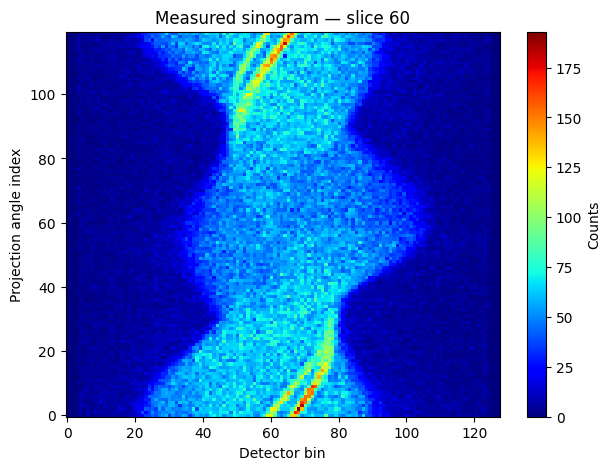

In [8]:
sinogram = sinograms[:nangle, nslice, :]

plt.figure(figsize=(7, 5))
plt.imshow(sinogram, origin="lower", cmap="jet", aspect="auto")
plt.colorbar(label="Counts")
plt.xlabel("Detector bin")
plt.ylabel("Projection angle index")
plt.title(f"Measured sinogram — slice {nslice}")
plt.show()


## 4. Create or load the geometric projection matrix

A purely geometric system matrix is generated using the **Radon transform**. Each image pixel is treated as a basis image and projected over all acquisition angles. Because this calculation is relatively slow, the resulting matrix is cached in `pmatrix_geo.pk` and reused in subsequent runs.


In [9]:
def writedata(df, fname):
    with open(fname, "wb") as f:
        pk.dump(df, f)


def readdata(fname):
    with open(fname, "rb") as f:
        return pk.load(f)


angles = np.linspace(0, 360, nangle, endpoint=False)

if not Path(pmatrix_geo_file).exists():
    N = ndim
    pmatrix_geo = np.zeros((len(angles) * nrays, N * N))

    for i in tqdm(range(N * N), desc="Building Radon matrix"):
        basis_img = np.zeros((N, N))
        row, col = divmod(i, N)
        basis_img[row, col] = 1.0

        sinogram_temp = radon(basis_img, theta=angles, circle=True)
        pmatrix_geo[:, i] = sinogram_temp.T.flatten()

    print(f"Projection matrix shape: {pmatrix_geo.shape}")
    pmatrix_geo = pmatrix_geo / pmatrix_geo.max()
    writedata(pmatrix_geo, pmatrix_geo_file)
else:
    print(f"Loading pre-existing geometric projection matrix: {pmatrix_geo_file}")
    pmatrix_geo = readdata(pmatrix_geo_file)

print("Geometric matrix shape:", pmatrix_geo.shape)


Loading pre-existing geometric projection matrix: pmatrix_geo.pk
Geometric matrix shape: (15360, 16384)


## 5. Reference MLEM reconstruction


In [10]:
sinogram_gpu = tf.constant(sinogram.ravel(), dtype=tf.float32)
pmatrix_geo_gpu = tf.constant(pmatrix_geo, dtype=tf.float32)


2026-09-07 21:24:41.888997: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2026-09-07 21:24:41.889082: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 36.00 GB
2026-09-07 21:24:41.889098: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 14.04 GB
I0000 00:00:1788805481.889125 4571520 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1788805481.889180 4571520 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [11]:
def smear(image, d):
    """Local box-average smoothing with radius d pixels."""
    image = np.asarray(image)
    kernel = np.ones((2 * d + 1, 2 * d + 1))
    sums = convolve(image, kernel, mode="constant", cval=0)
    num_neighbors = convolve(np.ones_like(image), kernel, mode="constant", cval=0)
    return sums / num_neighbors


def normimg(img):
    """Normalize an image by its finite mean value."""
    return img / np.nanmean(img)


MLEM is used here as a deterministic reference reconstruction. The HMC results below should not be interpreted simply as another point estimate: the main HMC output is an ensemble of images sampled from the reconstruction probability distribution.


In [12]:
image_mlem, _, _, _ = mlem_reconstruction(
    pmatrix_geo_gpu,
    sinogram_gpu,
    ndim,
    n_iter=1000,
    epsilon=0.001,
    normalize_at_end=False,
    auto_converge=True,
    printout=True
)


|██████████████████████████████████████████████----|  93.50% 101.359
Converged at iteration 936: relative change = 9.635e-06, chi2_loss = 101.358

final chi2_loss = 101.3576
iterations used = 936
cpu_time = 15.05859899520874


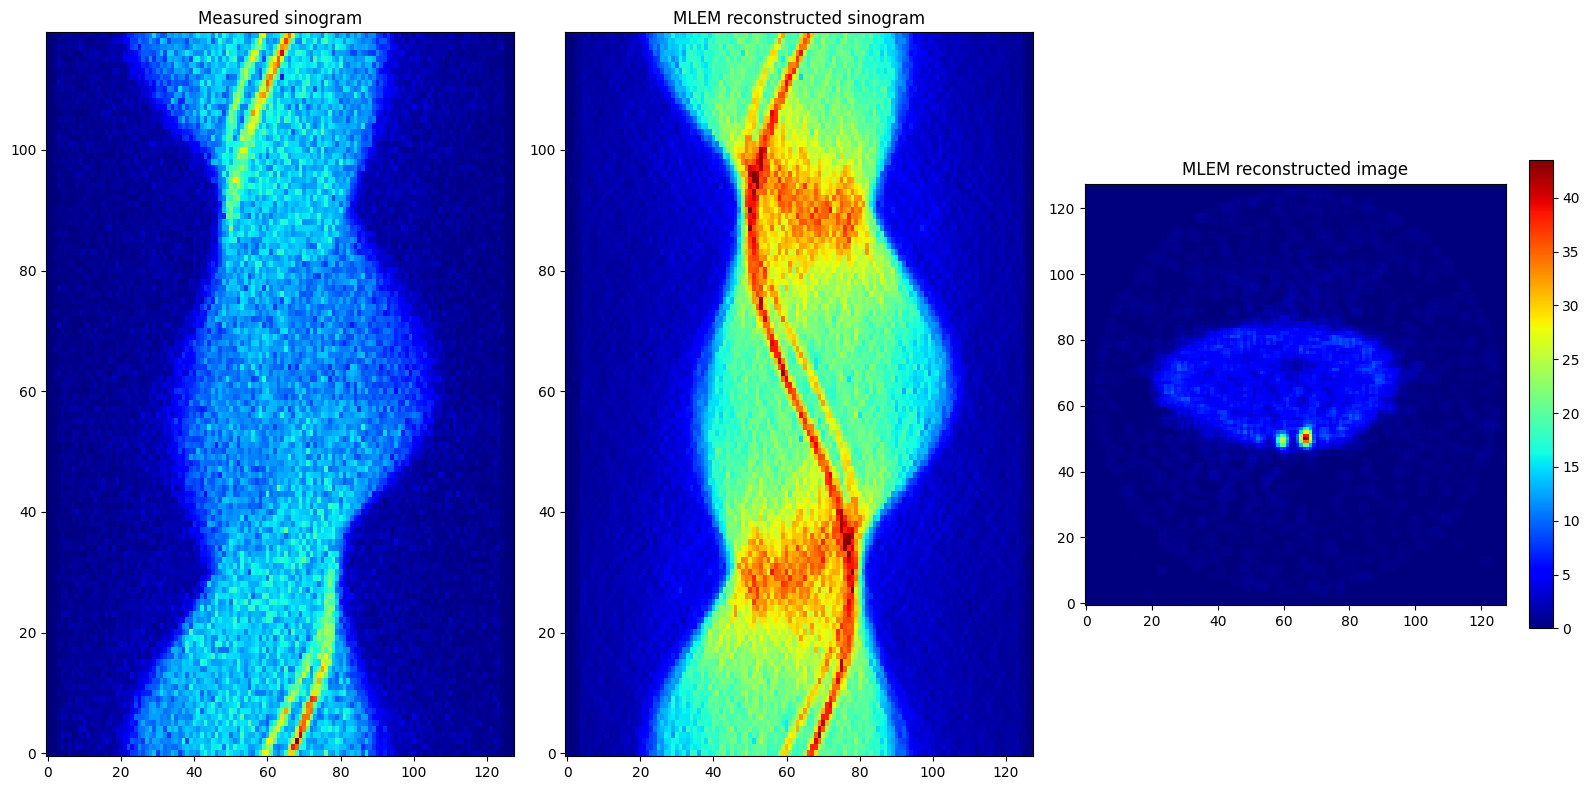

In [13]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.imshow(sinogram, cmap="jet", origin="lower", aspect="auto")
plt.title("Measured sinogram")

plt.subplot(1, 3, 2)
rsinogram_mlem = np.dot(
    pmatrix_geo.reshape(nrays * nangle, ndim * ndim),
    image_mlem.numpy().ravel(),
)
plt.imshow(rsinogram_mlem.reshape(nangle, nrays), cmap="jet", origin="lower", aspect="auto")
plt.title("MLEM reconstructed sinogram")

plt.subplot(1, 3, 3)
plt.imshow(smear(normimg(image_mlem), 1), cmap="jet", origin="lower")
plt.colorbar(fraction=0.05)
plt.title("MLEM reconstructed image")

plt.tight_layout()
plt.show()


## 6. HMC reconstruction — geometric model

The first HMC calculation uses only the geometric projection matrix.

### Main HMC parameters

- `Temperature` — temperature parameter controlling the sampled distribution.
- `nini` — number of initialization iterations.
- `ntherm` — number of thermalization stages.
- `num_samples` — number of reconstructed images retained in the ensemble.
- `nthread` — number of parallel HMC chains/threads used by the implementation.
- `step0` — initial HMC integration-step parameter.
- `factor` — trajectory/adaptation scaling factor.
- `target_accept` — target HMC acceptance probability.
- `positivity_mode='reflect'` — imposes non-negative activity by reflecting trajectories at the positivity boundary.

The returned dictionary contains, among other quantities:

- `res['all_images']` — ensemble of accepted reconstructed images.
- `res['chi2list']` — χ² values associated with the sampled states.


In [14]:
Temperature = 1
nini = 100
ntherm = 3
num_samples = 400
nthread = 10
step0 = 10
fraction = 1
factor = 1.25
maxstep = None

res = HMC_reconstruction(
    sinogram,
    pmatrix_geo_gpu,
    ndim,
    nini=nini,
    ntherm=ntherm,
    num_samples=num_samples,
    nthread=nthread,
    factor=factor,
    T=Temperature,
    printout=True,
    L0=10,
    AMIAS=True,
    mask=None,
    force_positive=True,
    step0=step0,
    maxstep=maxstep,
    mass=1.0,
    fraction=fraction,
    positivity_mode="reflect",
    adapt0=0.25,
    adapt_power=0,
    target_accept=0.7,
    getensemble=True,
    max_overshoot=0.1,
)


initialization: internal sgd_reconstruction
[------------------------------]   0.01% | Loss=26.086451 | Chi2=26.086451 | LR=1.000e-01

2026-09-07 21:25:13.729901: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


[=======-----------------------]  23.01% | Loss=1.65171 | Chi2=1.65171 | LR=1.261e-02e-02
Stopped automatically at iteration 2344. Loss = 1.6516862, best loss = 1.6516862

best loss = 1.6516862  (chi2)
final reconstructed / experimental counts = 0.93938229
Automatic convergence stop was activated.
temperature ladder: [1.         1.25       1.5625     1.953125   2.44140625 3.05175781
 3.81469727 4.76837158 5.96046448 7.4505806 ]
initial value of objective function = [1.65168607 1.65168607 1.65168607 1.65168607 1.65168607 1.65168607
 1.65168607 1.65168607 1.65168607 1.65168607]
initial energy = [1.65168607 1.65168607 1.65168607 1.65168607 1.65168607 1.65168607
 1.65168607 1.65168607 1.65168607 1.65168607]
current_objective = [1.65168607 1.65168607 1.65168607 1.65168607 1.65168607 1.65168607
 1.65168607 1.65168607 1.65168607 1.65168607]
|████████████████████████████| 100.00% cold_chain=7 T=1 chi2=5.612085342407e+00 step=6.767436e+00 cold_acc=0.686 recent_acc=0.660 recent_prob=0.699 recent

### HMC convergence and ensemble mean


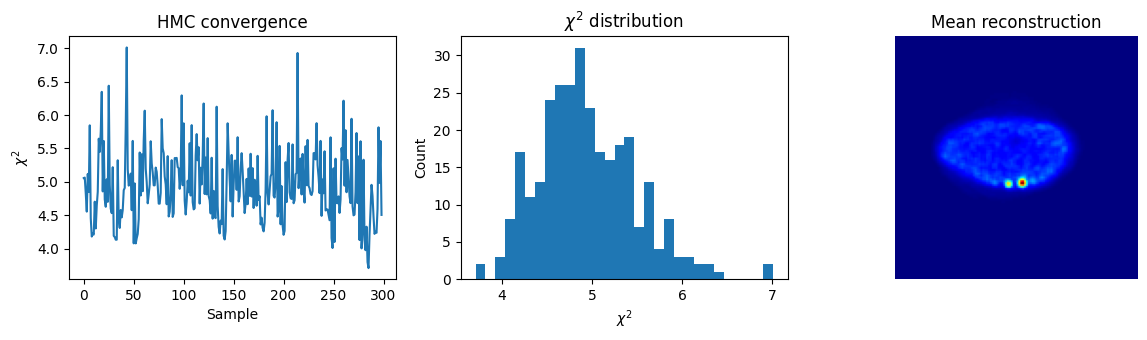

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))

chi2 = np.asarray(res['chi2list'])

ax[0].plot(chi2, lw=1.5)
ax[0].set(xlabel='Sample', ylabel=r'$\chi^2$', title='HMC convergence')

ax[1].hist(chi2[chi2 < 10], bins=30)
ax[1].set(xlabel=r'$\chi^2$', ylabel='Count', title=r'$\chi^2$ distribution')

ax[2].imshow(smear(np.mean(res['all_images'], axis=0), 1), cmap='jet',origin='lower')
ax[2].set_title('Mean reconstruction')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Ensemble correlations

The correlation diagnostic evaluates how strongly successive ensemble samples remain correlated. Large correlations over many lags indicate slower mixing and therefore fewer effectively independent samples.


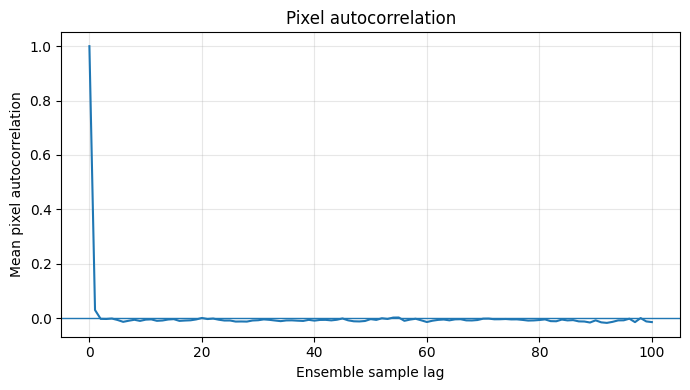

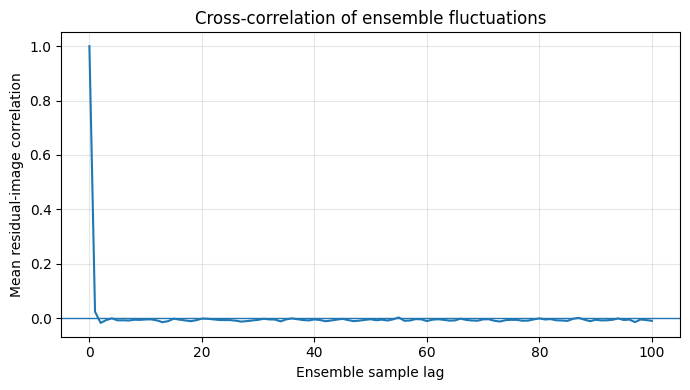

In [16]:
corr_results = plot_ensemble_correlations(
np.asarray(res["all_images"][::2]),
max_lag=100,
mask=None
)

### Define a support mask from the ensemble mean


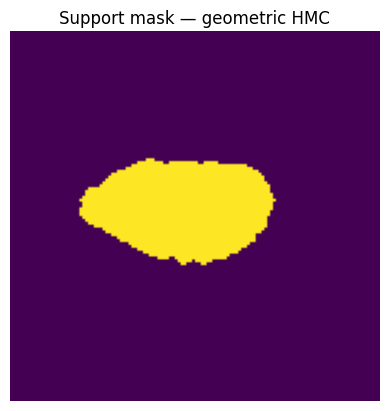

In [17]:
mask_geo = smear(np.mean(res["all_images"], axis=0), 1) > 1
mask_geo = binary_fill_holes(mask_geo)

plt.imshow(mask_geo, origin="lower")
plt.title("Support mask — geometric HMC")
plt.axis("off")
plt.show()


### Compare measured sinogram, reconstructed sinogram, and HMC mean image


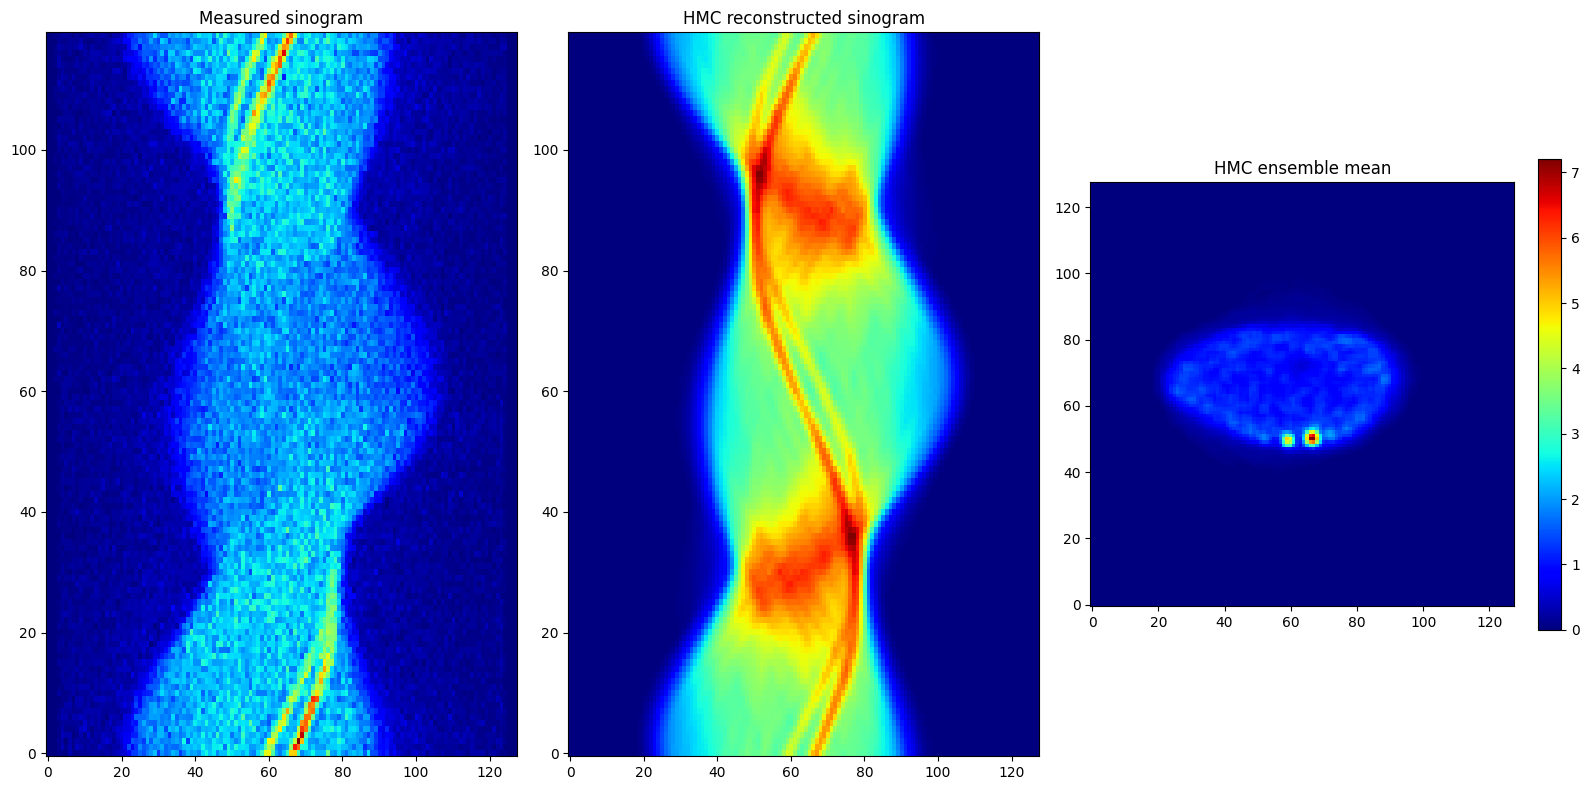

In [18]:
image_HMC = smear(np.mean(res["all_images"], axis=0), 1)

plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.imshow(sinogram, cmap="jet", origin="lower", aspect="auto")
plt.title("Measured sinogram")

plt.subplot(1, 3, 2)
rsinogram_hmc = np.dot(
    pmatrix_geo.reshape(nrays * nangle, ndim * ndim),
    image_HMC.ravel(),
)
plt.imshow(rsinogram_hmc.reshape(nangle, nrays), cmap="jet", origin="lower", aspect="auto")
plt.title("HMC reconstructed sinogram")

plt.subplot(1, 3, 3)
plt.imshow(image_HMC, cmap="jet", origin="lower")
plt.colorbar(fraction=0.05)
plt.title("HMC ensemble mean")

plt.tight_layout()
plt.show()


### Data-visible ensemble diagnostics

The following diagnostic separates fluctuations in image space from the part of those fluctuations that is directly visible through the forward model. This helps distinguish uncertainty modes that strongly affect the measured data from modes that are weakly constrained by the acquisition.


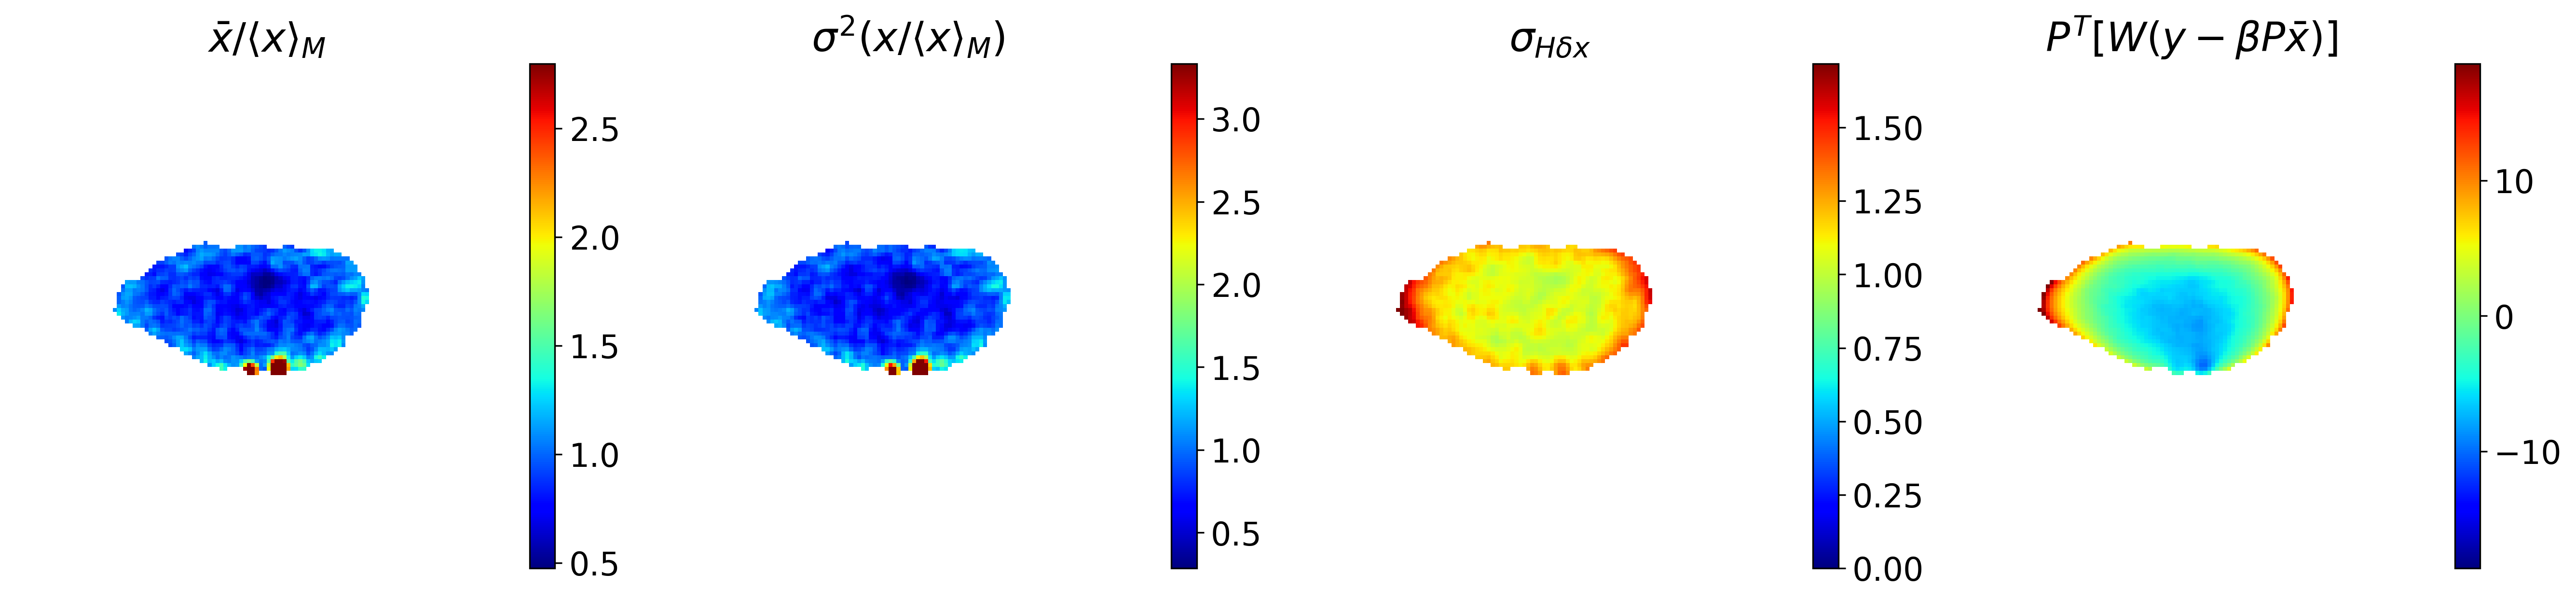

Normalization used: True
Mean normalization region: mask
Weight floor: 0.24
Alpha: 1.0
Best-fit beta for residual: 1.7554701466116946
Display mask erosion: 0


In [19]:
out_geo = plot_data_visible_maps_tf(
    images=res["all_images"],
    pmatrix=pmatrix_geo_gpu,
    sinogram=sinogram,
    eps=1.0e-7,
    mask=mask_geo,
    use_alpha=False,
    vmin=[None, None, 0, None],
    vmax=[None, None, None, None],
    savefig=False,
)


## 7. Construct the GATE-corrected projection matrix

The second forward model combines the geometric matrix with voxel-dependent projection information obtained from GATE. For the selected slice, each geometric matrix element is multiplied by the corresponding GATE-derived voxel response. The resulting matrix therefore incorporates the spatially dependent effects represented in the GATE simulation, including attenuation/scatter information used in this example.

The GATE projection data are loaded from `projections_ideal_WC.pk`.


In [20]:
projections = readdata(projections_file)
print("GATE projection array shape:", np.asarray(projections).shape)


GATE projection array shape: (120, 128, 128, 128)


In [21]:
pmatrix_gate = np.zeros((nangle, nrays, ndim, ndim))
pmatrix_geo_4d = pmatrix_geo.reshape(nangle, nrays, ndim, ndim)

for iang in range(nangle):
    for iray in range(nrays):
        pmatrix_gate[iang, iray, :, :] = (
            pmatrix_geo_4d[iang, iray, :, :] * projections[iang, nslice, :, :]
        )

pmatrix_gate = pmatrix_gate / pmatrix_gate.max()
print("GATE-corrected matrix shape:", pmatrix_gate.shape)


GATE-corrected matrix shape: (120, 128, 128, 128)


### Inspect representative geometric, GATE-response, and corrected matrix elements


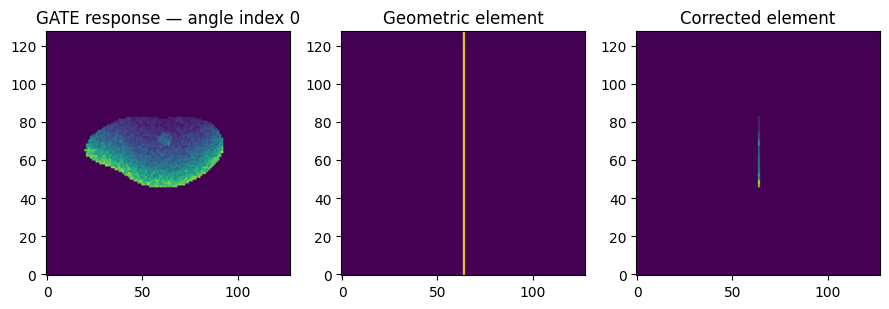

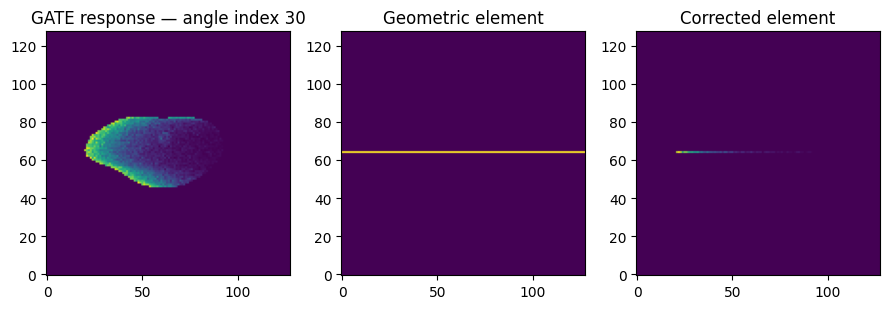

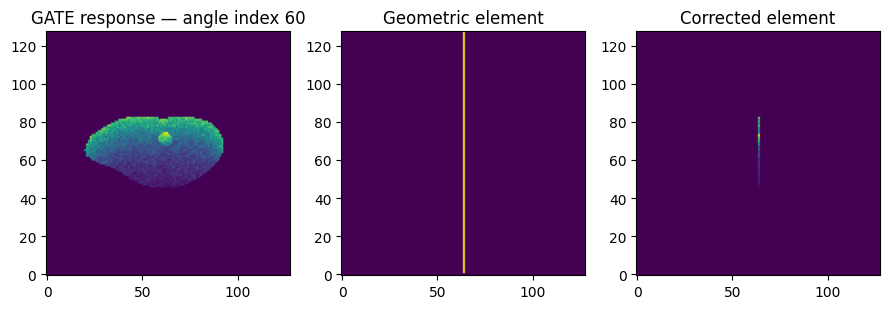

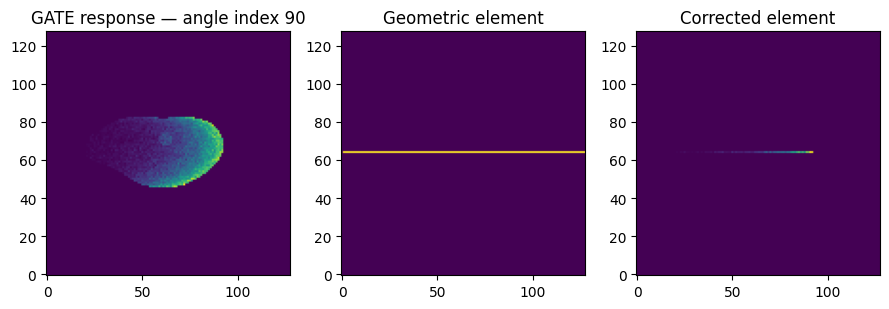

In [22]:
for i in range(nangle):
    if i % 30 == 0:
        plt.figure(figsize=(9, 4))

        plt.subplot(1, 3, 1)
        plt.imshow(projections[i, nslice, :, :], origin="lower")
        plt.title(f"GATE response — angle index {i}")

        plt.subplot(1, 3, 2)
        plt.imshow(pmatrix_geo_4d[i, 64, :, :], origin="lower")
        plt.title("Geometric element")

        plt.subplot(1, 3, 3)
        plt.imshow(pmatrix_gate[i, 64, :, :], origin="lower")
        plt.title("Corrected element")

        plt.tight_layout()
        plt.show()


In [23]:
pmatrix_gate_gpu = tf.constant(
    pmatrix_gate.reshape(nangle * nrays, ndim**2),
    dtype=tf.float32,
)


## 8. HMC reconstruction — GATE-corrected model

The HMC calculation is repeated with the GATE-corrected forward model. The same sampling parameters are retained so that differences can be attributed primarily to the change in the system model.


In [24]:
res_gate = HMC_reconstruction(
    sinogram,
    pmatrix_gate_gpu,
    ndim,
    nini=nini,
    ntherm=ntherm,
    num_samples=num_samples,
    nthread=nthread,
    factor=factor,
    T=Temperature,
    printout=True,
    L0=10,
    AMIAS=True,
    mask=None,
    force_positive=True,
    step0=step0,
    maxstep=maxstep,
    mass=1.0,
    fraction=fraction,
    positivity_mode="reflect",
    adapt0=0.25,
    adapt_power=0,
    target_accept=0.7,
    getensemble=True,
    max_overshoot=0.1,
)


initialization: internal sgd_reconstruction
[=============-----------------]  42.01% | Loss=3.0919092 | Chi2=3.0919092 | LR=2.355e-03
Stopped automatically at iteration 4240. Loss = 3.0918684, best loss = 3.0918684

best loss = 3.0918684  (chi2)
final reconstructed / experimental counts = 0.86975856
Automatic convergence stop was activated.
temperature ladder: [1.         1.25       1.5625     1.953125   2.44140625 3.05175781
 3.81469727 4.76837158 5.96046448 7.4505806 ]
initial value of objective function = [3.09186816 3.09186816 3.09186816 3.09186816 3.09186816 3.09186816
 3.09186816 3.09186816 3.09186816 3.09186816]
initial energy = [3.09186816 3.09186816 3.09186816 3.09186816 3.09186816 3.09186816
 3.09186816 3.09186816 3.09186816 3.09186816]
current_objective = [3.09186816 3.09186816 3.09186816 3.09186816 3.09186816 3.09186816
 3.09186816 3.09186816 3.09186816 3.09186816]
|████████████████████████████| 100.00% cold_chain=0 T=1 chi2=3.101616859436e+00 step=6.458555e+01 cold_acc=0.7

### HMC convergence and ensemble mean — GATE-corrected model


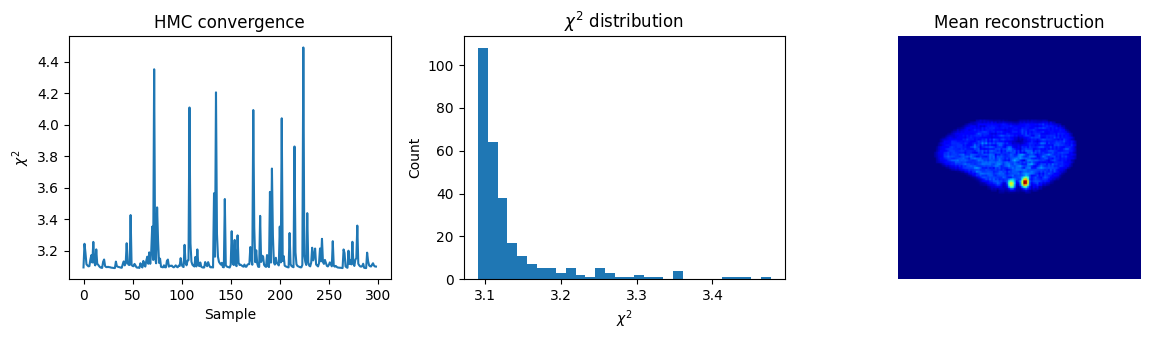

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.5))

chi2 = np.asarray(res_gate['chi2list'])

ax[0].plot(chi2, lw=1.5)
ax[0].set(xlabel='Sample', ylabel=r'$\chi^2$', title='HMC convergence')

ax[1].hist(chi2[chi2 < 3.5], bins=30)
ax[1].set(xlabel=r'$\chi^2$', ylabel='Count', title=r'$\chi^2$ distribution')

ax[2].imshow(smear(np.mean(res_gate['all_images'], axis=0), 1), cmap='jet',origin='lower')
ax[2].set_title('Mean reconstruction')
ax[2].axis('off')

plt.tight_layout()
plt.show()

### Ensemble correlations — GATE-corrected model


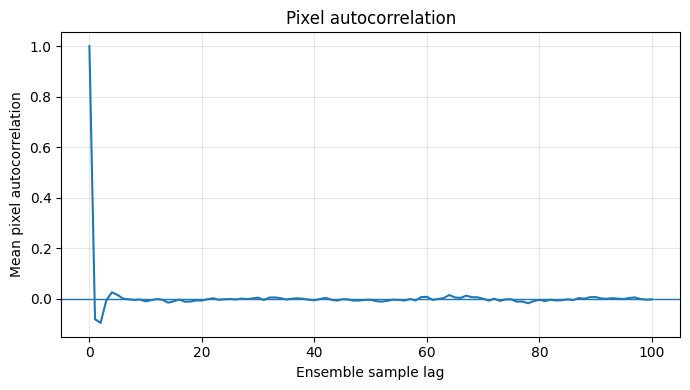

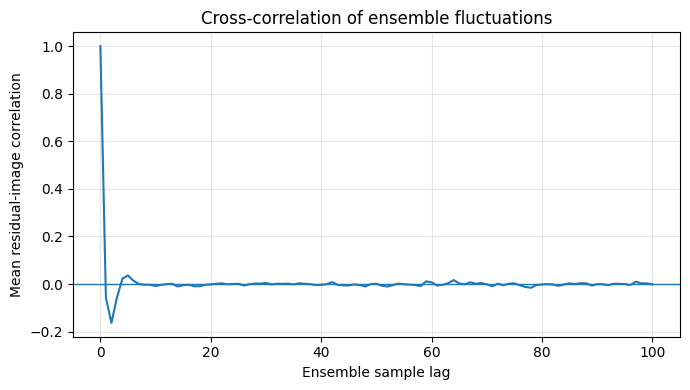

In [26]:
corr_results = plot_ensemble_correlations(
np.asarray(res_gate["all_images"]),
max_lag=100,
mask=None
)

### Define a support mask from the corrected ensemble mean


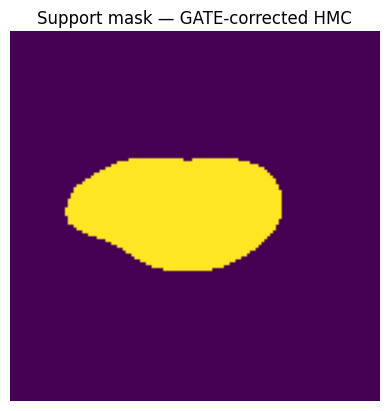

In [27]:
mask_gate = smear(np.mean(res_gate["all_images"], axis=0), 1) > 0
mask_gate = binary_fill_holes(mask_gate)

plt.imshow(mask_gate, origin="lower")
plt.title("Support mask — GATE-corrected HMC")
plt.axis("off")
plt.show()


### Compare measured sinogram, reconstructed sinogram, and corrected HMC mean image


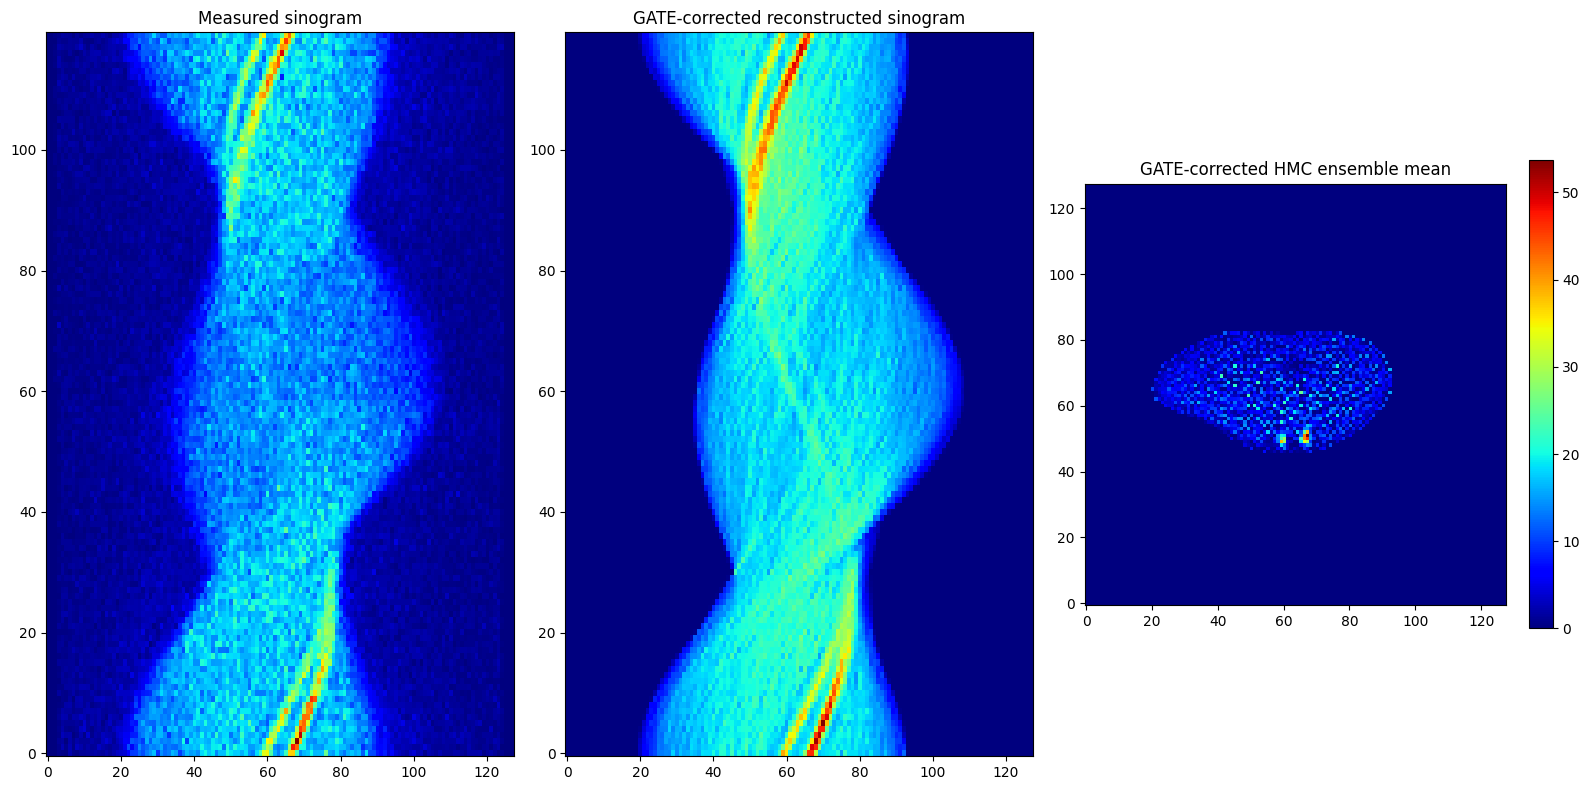

In [28]:
image_HMC_gate = np.mean(res_gate["all_images"], axis=0)

plt.figure(figsize=(16, 8))

plt.subplot(1, 3, 1)
plt.imshow(sinogram, cmap="jet", origin="lower", aspect="auto")
plt.title("Measured sinogram")

plt.subplot(1, 3, 2)
rsinogram_gate = np.dot(
    pmatrix_gate.reshape(nrays * nangle, ndim * ndim),
    image_HMC_gate.ravel(),
)
plt.imshow(rsinogram_gate.reshape(nangle, nrays), cmap="jet", origin="lower", aspect="auto")
plt.title("GATE-corrected reconstructed sinogram")

plt.subplot(1, 3, 3)
plt.imshow(image_HMC_gate, cmap="jet", origin="lower")
plt.colorbar(fraction=0.05)
plt.title("GATE-corrected HMC ensemble mean")

plt.tight_layout()
plt.show()


### Data-visible ensemble diagnostics — GATE-corrected model


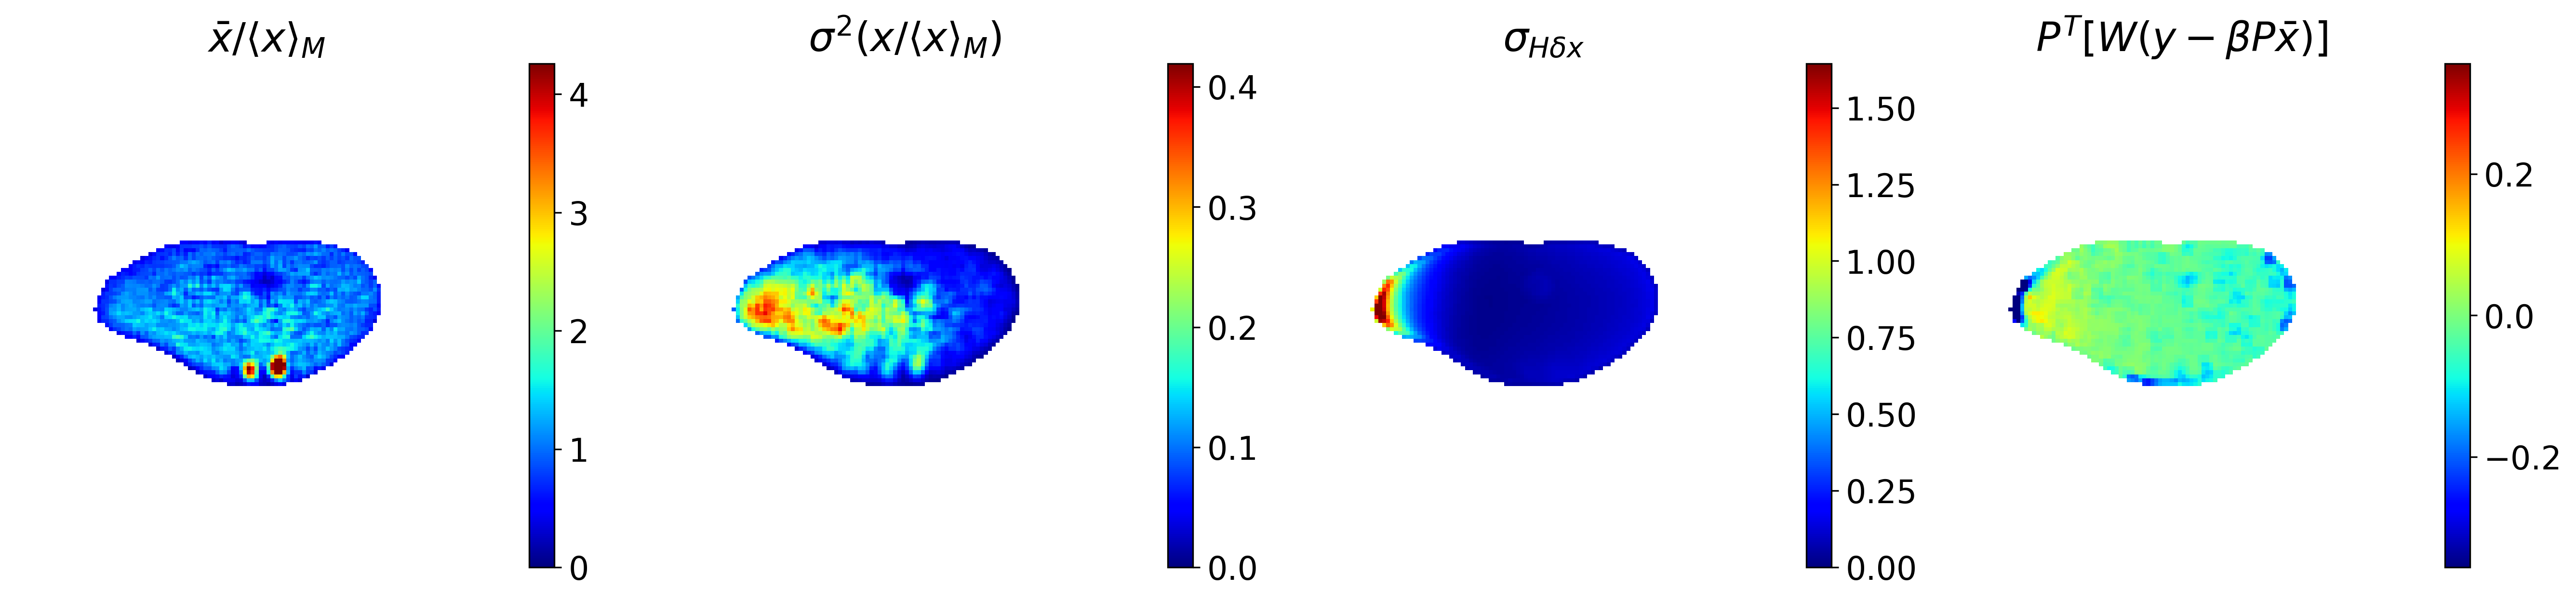

Normalization used: True
Mean normalization region: mask
Weight floor: 0.24
Alpha: 1.0
Best-fit beta for residual: 4.958587012087566
Display mask erosion: 0


In [29]:
out_gate = plot_data_visible_maps_tf(
    images=res_gate["all_images"],
    pmatrix=pmatrix_gate_gpu,
    sinogram=sinogram,
    eps=1.0e-7,
    mask=mask_gate,
    use_alpha=False,
    vmin=[None, None, 0, None],
    vmax=[None, None, None, None],
    savefig=False,
)


## 9. Interpretation

The notebook provides two HMC ensembles generated from the same measured sinogram but with different forward models:

- `res` — geometric system model.
- `res_gate` — GATE-corrected system model.

Useful comparisons include:

- ensemble-mean reconstructed images;
- χ² evolution and χ² distributions;
- sample autocorrelation / effective mixing;
- image-space variance;
- data-visible fluctuation maps;
- agreement between measured and reconstructed sinograms.

The key methodological point is that HMC provides access to an **ensemble of plausible reconstructions**, enabling uncertainty and correlation information to be studied in addition to the conventional reconstructed image.


## PERSPECT project and citation

This notebook is shared as part of the dissemination activities of the **PERSPECT — Personalized SPECT** project.

Project website: [https://perspect.frederick.ac.cy](https://perspect.frederick.ac.cy)

If this implementation contributes to your work, please consider citing:

*Hamiltonian dynamics for stochastic reconstruction in emission tomography*, T. Leontiou et al., Physics in Medicine and Biology, 2026.

For questions, feedback, or possible collaboration, please contact **Theodoros Leontiou, Frederick University, Cyprus**

at **t.leontiou@frederick.ac.cy**
